# 0. Install and Import Dependencies

In [1]:
!pip install mediapipe~=0.10.9 opencv-python~=4.9.0.80 pandas scikit-learn~=1.4.0

  Using cached mediapipe-0.10.14-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached pandas-2.2.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached scikit_learn-1.4.2-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached jax-0.4.30-py3-none-any.whl.metadata (22 kB)
  Using cached jaxlib-0.4.30-cp39-cp39-manylinux2014_x86_64.whl.metadata (1.0 kB)
  Using cached matplotlib-3.9.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached opencv_contrib_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached sounddevice-0.4.7-py3-none-any.whl.metadata (1.4 kB)
  Using cached pytz-2024.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2024.1-py2.py3-none-any.whl.metadata (1.4 kB)


In [1]:
import mediapipe as mp # Import mediapipe
import cv2 # Import opencv
import time

2026-03-13 15:37:50.201652: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 15:37:50.202442: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 15:37:50.204217: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 15:37:50.209889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773409070.219557  247227 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773409070.22

In [2]:
mp_drawing = mp.solutions.drawing_utils # Drawing helpers
mp_holistic = mp.solutions.holistic # Mediapipe Solutions

In [3]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


W0000 00:00:1773409071.588102  247227 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# 1. Make Some Detections

In [4]:
cap = cv2.VideoCapture(0)

# Initiate holistic model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
   
    start_time = time.time()  # Record the start time
   
    while cap.isOpened():
        if time.time() - start_time > 10:  # Check if 30 seconds have passed
            break
       
        ret, frame = cap.read()
       
        # Process frame if it's successfully captured
        if ret:
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
            results = holistic.process(image)
            image.flags.writeable = True
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

            # Drawing landmarks
            if results.face_landmarks:
                mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
                                          mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=1, circle_radius=1),
                                          mp_drawing.DrawingSpec(color=(80, 256, 121), thickness=1, circle_radius=1))
            if results.right_hand_landmarks:
                mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                          mp_drawing.DrawingSpec(color=(80, 22, 10), thickness=2, circle_radius=4),
                                          mp_drawing.DrawingSpec(color=(80, 44, 121), thickness=2, circle_radius=2))
            if results.left_hand_landmarks:
                mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                          mp_drawing.DrawingSpec(color=(121, 22, 76), thickness=2, circle_radius=4),
                                          mp_drawing.DrawingSpec(color=(121, 44, 250), thickness=2, circle_radius=2))
            if results.pose_landmarks:
                mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                                          mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=4),
                                          mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2))

            cv2.imshow('Raw Webcam Feed', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1773409073.330991  247227 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773409073.369727  248063 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.183.06), renderer: NVIDIA GeForce RTX 2080 Ti/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773409073.414543  248048 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773409073.427525  248061 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773409073.428318  248048 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773409073.428354  248060 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inf

# 2. Capture Landmarks & Export to CSV
<!--<img src="https://i.imgur.com/8bForKY.png">-->
<!--<img src="https://i.imgur.com/AzKNp7A.png">-->

In [29]:
#
import csv
import os
import numpy as np
import cv2
import mediapipe as mp
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam

# Initialize Mediapipe Holistic model and Drawing utilities
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# Function to calculate velocity
def calculate_velocity(landmarks):
    velocities = []
    for i in range(1, len(landmarks)):
        velocity = np.linalg.norm(landmarks[i] - landmarks[i-1])
        velocities.append(velocity)
    return np.array(velocities)

# Function to calculate acceleration
def calculate_acceleration(velocities):
    accelerations = []
    for i in range(1, len(velocities)):
        acceleration = np.abs(velocities[i] - velocities[i-1])
        accelerations.append(acceleration)
    return np.array(accelerations)

# Function to identify keyframes based on velocity and acceleration
def identify_keyframes(landmarks, velocity_threshold=0.1, acceleration_threshold=0.1):
    velocities = calculate_velocity(landmarks)
    accelerations = calculate_acceleration(velocities)
    keyframes = []
    for i in range(len(accelerations)):
        if velocities[i] > velocity_threshold or accelerations[i] > acceleration_threshold:
            keyframes.append(i + 1)  # +1 because acceleration index starts from 1
    return keyframes

# Function to calculate the angle between three points
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

# Define the class name for the gesture

class_name = "Im hungry"
#class_name = "Me"
#class_name = "Bye bye"
#class_name = "Thank you"
#class_name = "Stop"
#class_name = "I am thirsty"
#class_name = "Yes"
#class_name = "No"

# Define the number of landmarks and angles
num_pose_landmarks = 33
num_hand_landmarks = 21
num_face_landmarks = 468
num_angles = 14  # Number of hand angles calculated

# Initialize video capture
cap = cv2.VideoCapture(0)

# Start Holistic model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    start_time = time.time()
    all_landmarks = []

    frame_number = 0  # To keep track of frame numbers for logging

    while cap.isOpened():
        if time.time() - start_time > 90:  # 180-second capture
            break

        ret, frame = cap.read()
        if not ret:
            break

        # Recolor Feed
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False

        # Make Detections
        results = holistic.process(image)

        # Recolor back to BGR
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Draw landmarks
        mp_drawing.draw_landmarks(
            image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
            mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80, 256, 121), thickness=1, circle_radius=1)
        )
        mp_drawing.draw_landmarks(
            image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121, 22, 76), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(121, 44, 250), thickness=2, circle_radius=2)
        )
        mp_drawing.draw_landmarks(
            image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
        )

        try:
            frame_number += 1  # Increment frame number
            landmarks = []

            # Extract pose landmarks
            if results.pose_landmarks:
                for landmark in results.pose_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.visibility])
            else:
                # Append zeros for missing pose landmarks
                landmarks.extend([0] * num_pose_landmarks * 3)
                print(f"Frame {frame_number}: Pose landmarks not detected.")

            # Extract left hand landmarks
            if results.left_hand_landmarks:
                for landmark in results.left_hand_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.visibility])

                # Calculate angles for hand landmarks
                hand_landmarks = results.left_hand_landmarks.landmark

                thumb_mcp = calculate_angle(
                    [hand_landmarks[1].x, hand_landmarks[1].y],
                    [hand_landmarks[2].x, hand_landmarks[2].y],
                    [hand_landmarks[3].x, hand_landmarks[3].y]
                )
                thumb_ip = calculate_angle(
                    [hand_landmarks[2].x, hand_landmarks[2].y],
                    [hand_landmarks[3].x, hand_landmarks[3].y],
                    [hand_landmarks[4].x, hand_landmarks[4].y]
                )
                index_mcp = calculate_angle(
                    [hand_landmarks[0].x, hand_landmarks[0].y],
                    [hand_landmarks[5].x, hand_landmarks[5].y],
                    [hand_landmarks[6].x, hand_landmarks[6].y]
                )
                index_pip = calculate_angle(
                    [hand_landmarks[5].x, hand_landmarks[5].y],
                    [hand_landmarks[6].x, hand_landmarks[6].y],
                    [hand_landmarks[7].x, hand_landmarks[7].y]
                )
                index_dip = calculate_angle(
                    [hand_landmarks[6].x, hand_landmarks[6].y],
                    [hand_landmarks[7].x, hand_landmarks[7].y],
                    [hand_landmarks[8].x, hand_landmarks[8].y]
                )
                middle_mcp = calculate_angle(
                    [hand_landmarks[0].x, hand_landmarks[0].y],
                    [hand_landmarks[9].x, hand_landmarks[9].y],
                    [hand_landmarks[10].x, hand_landmarks[10].y]
                )
                middle_pip = calculate_angle(
                    [hand_landmarks[9].x, hand_landmarks[9].y],
                    [hand_landmarks[10].x, hand_landmarks[10].y],
                    [hand_landmarks[11].x, hand_landmarks[11].y]
                )
                middle_dip = calculate_angle(
                    [hand_landmarks[10].x, hand_landmarks[10].y],
                    [hand_landmarks[11].x, hand_landmarks[11].y],
                    [hand_landmarks[12].x, hand_landmarks[12].y]
                )
                ring_mcp = calculate_angle(
                    [hand_landmarks[0].x, hand_landmarks[0].y],
                    [hand_landmarks[13].x, hand_landmarks[13].y],
                    [hand_landmarks[14].x, hand_landmarks[14].y]
                )
                ring_pip = calculate_angle(
                    [hand_landmarks[13].x, hand_landmarks[13].y],
                    [hand_landmarks[14].x, hand_landmarks[14].y],
                    [hand_landmarks[15].x, hand_landmarks[15].y]
                )
                ring_dip = calculate_angle(
                    [hand_landmarks[14].x, hand_landmarks[14].y],
                    [hand_landmarks[15].x, hand_landmarks[15].y],
                    [hand_landmarks[16].x, hand_landmarks[16].y]
                )
                little_mcp = calculate_angle(
                    [hand_landmarks[0].x, hand_landmarks[0].y],
                    [hand_landmarks[17].x, hand_landmarks[17].y],
                    [hand_landmarks[18].x, hand_landmarks[18].y]
                )
                little_pip = calculate_angle(
                    [hand_landmarks[17].x, hand_landmarks[17].y],
                    [hand_landmarks[18].x, hand_landmarks[18].y],
                    [hand_landmarks[19].x, hand_landmarks[19].y]
                )
                little_dip = calculate_angle(
                    [hand_landmarks[18].x, hand_landmarks[18].y],
                    [hand_landmarks[19].x, hand_landmarks[19].y],
                    [hand_landmarks[20].x, hand_landmarks[20].y]
                )

                # Append angles to landmarks
                angles = [
                    thumb_mcp, thumb_ip, 
                    index_mcp, index_pip, index_dip, 
                    middle_mcp, middle_pip, middle_dip, 
                    ring_mcp, ring_pip, ring_dip, 
                    little_mcp, little_pip, little_dip
                ]
                landmarks.extend(angles)
            else:
                # Append zeros for missing hand landmarks and angles
                landmarks.extend([0] * num_hand_landmarks * 3)
                landmarks.extend([0] * num_angles)
                print(f"Frame {frame_number}: Left hand landmarks not detected.")

            # Extract face landmarks
            if results.face_landmarks:
                for landmark in results.face_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.visibility])
            else:
                # Append zeros for missing face landmarks
                landmarks.extend([0] * num_face_landmarks * 3)
                print(f"Frame {frame_number}: Face landmarks not detected.")

            # Check if the length of landmarks matches the expected total
            expected_length = (num_pose_landmarks + num_hand_landmarks + num_face_landmarks) * 3 + num_angles
            if len(landmarks) == expected_length:
                all_landmarks.append(landmarks)
            else:
                print(f"Frame {frame_number}: Unexpected number of landmarks ({len(landmarks)}), expected {expected_length}.")

        except Exception as e:
            print(f"Error in frame {frame_number}: {e}")

        # Display the resulting frame
        cv2.imshow('Raw Webcam Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    # Convert all landmarks to numpy array for processing
    all_landmarks = np.array(all_landmarks)

    # Identify keyframes
    keyframes = identify_keyframes(all_landmarks, velocity_threshold=0.1, acceleration_threshold=0.1)

    # Save keyframes to CSV
    sequence_id = 0
    frame_window = 5  # Number of frames to include before and after each keyframe

    with open('coords_movement_person1.csv', mode='a', newline='') as f:
        csv_writer = csv.writer(f, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)
        for kf in keyframes:
            sequence_id += 1
            start_idx = max(0, kf - frame_window)
            end_idx = min(len(all_landmarks), kf + frame_window + 1)
            for idx in range(start_idx, end_idx):
                row = [class_name, sequence_id] + list(all_landmarks[idx])
                csv_writer.writerow(row)

print("Keyframes and surrounding frames saved.")
#

Frame 3: Left hand landmarks not detected.
Frame 82: Left hand landmarks not detected.
Frame 84: Left hand landmarks not detected.
Frame 95: Left hand landmarks not detected.
Frame 115: Left hand landmarks not detected.
Frame 135: Left hand landmarks not detected.
Frame 146: Left hand landmarks not detected.
Frame 157: Left hand landmarks not detected.
Frame 174: Left hand landmarks not detected.
Frame 187: Left hand landmarks not detected.
Frame 226: Left hand landmarks not detected.
Frame 236: Left hand landmarks not detected.
Frame 253: Left hand landmarks not detected.
Frame 263: Left hand landmarks not detected.
Frame 265: Left hand landmarks not detected.
Frame 299: Left hand landmarks not detected.
Frame 312: Left hand landmarks not detected.
Frame 343: Left hand landmarks not detected.
Frame 373: Left hand landmarks not detected.
Frame 422: Left hand landmarks not detected.
Frame 433: Left hand landmarks not detected.
Frame 442: Left hand landmarks not detected.
Frame 475: Left

# 3. Train Custom Model Using Scikit Learn

## 3.1 Read in Collected Data and Process

In [3]:
#
import pandas as pd

# Load the data
df = pd.read_csv('coords_movement_9_10.csv')

# Print the number of rows and columns
num_rows = df.shape[0]
num_cols = df.shape[1]
print(f"The CSV file has {num_rows} rows and {num_cols} columns.")

# Print unique classes and their counts
class_counts = df['class'].value_counts()
print("Unique classes and their sample counts:")
print(class_counts)

# Ensure unique identifiers
df['unique_id'] = df['class'] + '_' + df['sequence_id'].astype(str)
unique_ids = df['unique_id'].unique()

# Print unique IDs and their count
print(f"Unique IDs: {unique_ids}")
print(f"Number of unique IDs: {len(unique_ids)}")
#

The CSV file has 218470 rows and 1582 columns.
Unique classes and their sample counts:
class
Me              29494
Bye bye         29471
Thank you       29460
Stop            29438
I am thirsty    29328
No              28315
Im hungry       28140
Yes             14824
Name: count, dtype: int64
Unique IDs: ['Im hungry_1' 'Im hungry_2' 'Im hungry_3' ... 'No_2573' 'No_2574'
 'No_2575']
Number of unique IDs: 19873


In [1]:
#
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the data
df = pd.read_csv('coords_movement_9_10.csv')

# Get the number of rows and columns
num_rows, num_cols = df.shape
print(f"The CSV file has {num_rows} rows and {num_cols} columns.")

# Ensure unique identifiers
df['unique_id'] = df['class'] + '_' + df['sequence_id'].astype(str)
unique_ids = df['unique_id'].unique()
print(f"Number of unique IDs: {len(unique_ids)}")

# Collect sequences and labels
sequences = []
labels = []

for unique_id in unique_ids:
    sequence_df = df[df['unique_id'] == unique_id]
    sequence_data = sequence_df.drop(columns=['class', 'sequence_id', 'unique_id']).values
    sequences.append(sequence_data)
    labels.append(sequence_df['class'].iloc[0])

# Pad sequences to the same length with a mask value not present in the data (e.g., -1)
X = pad_sequences(sequences, padding='post', dtype='float32', value=-1.0)
y = np.array(labels)

# Convert labels to integer encoding and one-hot encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)

# Print label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

# Normalize hand angles in X (positions 162 to 175)
angle_positions = np.arange(162, 176)
X[:, :, angle_positions] /= 180.0  # Normalize angles to [0, 1]

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)

# Print shapes for verification
print(f"X_train shape: {X_train.shape}")  # Expected: (num_sequences, max_sequence_length, num_features)
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")  # Expected: (num_sequences, num_classes)
print(f"y_test shape: {y_test.shape}")

# Compute class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# Build the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Masking(mask_value=-1.0, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model without callbacks
history = model.fit(
    X_train, y_train,
    epochs=50,  # You can adjust the number of epochs as needed
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict
)

# Save the final model
model.save('Movement_model_person1.h5')
print("Model saved as 'Movement_model_person1.h5'")

# Save the label encoder for future use
import joblib
joblib.dump(le, 'label_encoder_person1.pkl')
print("Label encoder saved as 'label_encoder_person1.pkl'")
#

2026-03-14 17:28:30.016927: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 17:28:30.029296: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-14 17:28:30.155921: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-14 17:28:30.252430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773502110.344307    3516 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773502110.36

The CSV file has 218470 rows and 1582 columns.
Number of unique IDs: 19873
Label Mapping: {'Bye bye': 0, 'I am thirsty': 1, 'Im hungry': 2, 'Me': 3, 'No': 4, 'Stop': 5, 'Thank you': 6, 'Yes': 7}
X_train shape: (15898, 11, 1580)
X_test shape: (3975, 11, 1580)
y_train shape: (15898, 8)
y_test shape: (3975, 8)
Class Weights: {0: 0.9265665796344648, 1: 0.9310813343328336, 2: 0.970361328125, 3: 0.9258758852031308, 4: 0.9647087378640776, 5: 0.9276045556385362, 6: 0.9269123134328359, 7: 1.842822700296736}


/home/user/anaconda3/envs/GR6/lib/python3.9/site-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1773502262.329261    3516 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 11, 1580)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 11, 128)        │       875,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
  5/497 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0962 - loss: 2.2054 

2026-03-14 17:31:04.473673: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


497/497 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4108 - loss: 1.3587 - val_accuracy: 0.8216 - val_loss: 0.4444
Epoch 2/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8431 - loss: 0.4254 - val_accuracy: 0.8921 - val_loss: 0.2590
Epoch 3/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8887 - loss: 0.2975 - val_accuracy: 0.9643 - val_loss: 0.1042
Epoch 4/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9402 - loss: 0.1684 - val_accuracy: 0.9711 - val_loss: 0.0837
Epoch 5/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9503 - loss: 0.1484 - val_accuracy: 0.9806 - val_loss: 0.0603
Epoch 6/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9675 - loss: 0.0968 - val_accuracy: 0.9869 - val_loss: 0.0349
Epoch 7/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9681 - loss: 0.0943 - val_accuracy: 0.9746 - val_loss: 0.0834
Epoch 8/50
497/497 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9693 - loss: 0.0907 - val_accuracy: 0.984

Model saved as 'Movement_model_person1.h5'
Label encoder saved as 'label_encoder_person1.pkl'


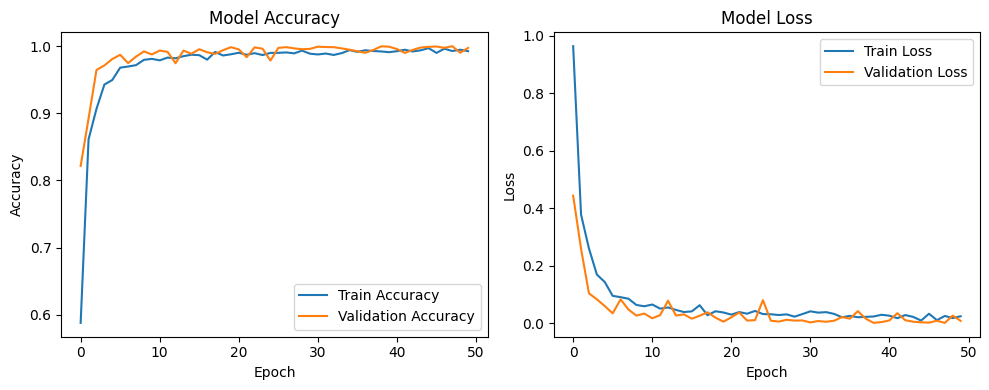

In [2]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [3]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9962 - loss: 0.0111
Test Accuracy: 99.72%


In [4]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Get predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print Classification Report
print('Classification Report')
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

# Create and display Confusion Matrix with class names
print('Confusion Matrix')
cm = confusion_matrix(y_true, y_pred_classes)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print(cm_df)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification Report
              precision    recall  f1-score   support

     Bye bye       1.00      1.00      1.00       536
I am thirsty       1.00      0.99      0.99       534
   Im hungry       1.00      1.00      1.00       512
          Me       1.00      1.00      1.00       537
          No       1.00      1.00      1.00       515
        Stop       0.98      1.00      0.99       536
   Thank you       1.00      1.00      1.00       536
         Yes       1.00      1.00      1.00       269

    accuracy                           1.00      3975
   macro avg       1.00      1.00      1.00      3975
weighted avg       1.00      1.00      1.00      3975

Confusion Matrix
              Bye bye  I am thirsty  Im hungry   Me   No  Stop  Thank you  Yes
Bye bye           534             0          0    0    0     2          0    0
I am thirsty        0           526          1    0    0     7          0    0
Im hungry           0           

In [5]:
# Load the label encoder
le = joblib.load('label_encoder_person1.pkl')

#
print("Classes:", le.classes_)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:")
for class_label, encoded_label in label_mapping.items():
    print(f"{class_label}: {encoded_label}")
#

Classes: ['Bye bye' 'I am thirsty' 'Im hungry' 'Me' 'No' 'Stop' 'Thank you' 'Yes']
Label Mapping:
Bye bye: 0
I am thirsty: 1
Im hungry: 2
Me: 3
No: 4
Stop: 5
Thank you: 6
Yes: 7


In [6]:
import cv2
import mediapipe as mp
from collections import deque
import numpy as np
import time
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib  # For loading the label encoder

# Initialize Mediapipe Holistic model and Drawing utilities
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# === Keyframe Logic Setup ===
# We need 5 before + 1 keyframe + 5 after = 11 total frames
sequence_length = 11  
frame_window = deque(maxlen=sequence_length)

# Cooldown to prevent spamming predictions on a single fast movement
prediction_cooldown = 0
COOLDOWN_FRAMES = 10 
current_gesture = "None"

# Load the trained model and label encoder
model = load_model('Movement_model_person1.h5')  
le = joblib.load('label_encoder_person1.pkl')
gesture_names = list(le.classes_)

# Function to calculate the angle between three points
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - \
              np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Initialize video capture
cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Recolor the frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Make detections
        results = holistic.process(image)
        
        # Recolor back to BGR for rendering
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        # Draw landmarks
        mp_drawing.draw_landmarks(
            image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
            mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
        )
        mp_drawing.draw_landmarks(
            image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
        )
        mp_drawing.draw_landmarks(
            image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
        )
        mp_drawing.draw_landmarks(
            image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
        )
        
        try:
            landmarks = []
            num_pose_landmarks = 33
            num_hand_landmarks = 21
            num_face_landmarks = 468
            num_angles = 14  
            
            # Extract pose landmarks
            if results.pose_landmarks:
                for landmark in results.pose_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.visibility])
            else:
                landmarks.extend([0] * num_pose_landmarks * 3)
            
            # Extract left hand landmarks and calculate angles
            if results.left_hand_landmarks:
                for landmark in results.left_hand_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.visibility])
                
                hand_landmarks = results.left_hand_landmarks.landmark
                
                thumb_mcp = calculate_angle([hand_landmarks[1].x, hand_landmarks[1].y], [hand_landmarks[2].x, hand_landmarks[2].y], [hand_landmarks[3].x, hand_landmarks[3].y])
                thumb_ip = calculate_angle([hand_landmarks[2].x, hand_landmarks[2].y], [hand_landmarks[3].x, hand_landmarks[3].y], [hand_landmarks[4].x, hand_landmarks[4].y])
                index_mcp = calculate_angle([hand_landmarks[0].x, hand_landmarks[0].y], [hand_landmarks[5].x, hand_landmarks[5].y], [hand_landmarks[6].x, hand_landmarks[6].y])
                index_pip = calculate_angle([hand_landmarks[5].x, hand_landmarks[5].y], [hand_landmarks[6].x, hand_landmarks[6].y], [hand_landmarks[7].x, hand_landmarks[7].y])
                index_dip = calculate_angle([hand_landmarks[6].x, hand_landmarks[6].y], [hand_landmarks[7].x, hand_landmarks[7].y], [hand_landmarks[8].x, hand_landmarks[8].y])
                middle_mcp = calculate_angle([hand_landmarks[0].x, hand_landmarks[0].y], [hand_landmarks[9].x, hand_landmarks[9].y], [hand_landmarks[10].x, hand_landmarks[10].y])
                middle_pip = calculate_angle([hand_landmarks[9].x, hand_landmarks[9].y], [hand_landmarks[10].x, hand_landmarks[10].y], [hand_landmarks[11].x, hand_landmarks[11].y])
                middle_dip = calculate_angle([hand_landmarks[10].x, hand_landmarks[10].y], [hand_landmarks[11].x, hand_landmarks[11].y], [hand_landmarks[12].x, hand_landmarks[12].y])
                ring_mcp = calculate_angle([hand_landmarks[0].x, hand_landmarks[0].y], [hand_landmarks[13].x, hand_landmarks[13].y], [hand_landmarks[14].x, hand_landmarks[14].y])
                ring_pip = calculate_angle([hand_landmarks[13].x, hand_landmarks[13].y], [hand_landmarks[14].x, hand_landmarks[14].y], [hand_landmarks[15].x, hand_landmarks[15].y])
                ring_dip = calculate_angle([hand_landmarks[14].x, hand_landmarks[14].y], [hand_landmarks[15].x, hand_landmarks[15].y], [hand_landmarks[16].x, hand_landmarks[16].y])
                little_mcp = calculate_angle([hand_landmarks[0].x, hand_landmarks[0].y], [hand_landmarks[17].x, hand_landmarks[17].y], [hand_landmarks[18].x, hand_landmarks[18].y])
                little_pip = calculate_angle([hand_landmarks[17].x, hand_landmarks[17].y], [hand_landmarks[18].x, hand_landmarks[18].y], [hand_landmarks[19].x, hand_landmarks[19].y])
                little_dip = calculate_angle([hand_landmarks[18].x, hand_landmarks[18].y], [hand_landmarks[19].x, hand_landmarks[19].y], [hand_landmarks[20].x, hand_landmarks[20].y])
                
                angles = [
                    thumb_mcp, thumb_ip,
                    index_mcp, index_pip, index_dip,
                    middle_mcp, middle_pip, middle_dip,
                    ring_mcp, ring_pip, ring_dip,
                    little_mcp, little_pip, little_dip
                ]
                landmarks.extend(angles)
            else:
                landmarks.extend([0] * num_hand_landmarks * 3)
                landmarks.extend([0] * num_angles)
            
            # Extract face landmarks
            if results.face_landmarks:
                for landmark in results.face_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.visibility])
            else:
                landmarks.extend([0] * num_face_landmarks * 3)
            
            expected_length = (num_pose_landmarks + num_hand_landmarks + num_face_landmarks) * 3 + num_angles
            
            if len(landmarks) == expected_length:
                # Normalize angles
                angle_positions = np.arange(162, 176)
                landmarks = np.array(landmarks)
                landmarks[angle_positions] /= 180.0  
                
                # Append to rolling window
                frame_window.append(landmarks)
            
            # Decrease cooldown if active
            if prediction_cooldown > 0:
                prediction_cooldown -= 1

            # === REAL-TIME KEYFRAME DETECTION ===
            if len(frame_window) == sequence_length and prediction_cooldown == 0:
                # frame_window[5] is the middle frame (the candidate keyframe)
                # frame_window[4] is the frame right before it
                # frame_window[3] is two frames before
                
                v_curr = np.linalg.norm(frame_window[5] - frame_window[4])
                v_prev = np.linalg.norm(frame_window[4] - frame_window[3])
                acceleration = np.abs(v_curr - v_prev)
                
                # Check if the middle frame is a keyframe based on your thresholds
                if v_curr > 0.1 or acceleration > 0.1:
                    print("⚡ Keyframe detected! Triggering prediction...")
                    
                    # Prepare input for the model
                    X_input = np.array(frame_window)
                    X_input = np.expand_dims(X_input, axis=0)  # Shape: (1, 11, num_features)
                    
                    # Predict gesture
                    y_pred = model.predict(X_input, verbose=0)
                    gesture_index = np.argmax(y_pred, axis=1)[0]
                    current_gesture = gesture_names[gesture_index]
                    
                    # Activate cooldown to prevent predicting the same gesture multiple times
                    prediction_cooldown = COOLDOWN_FRAMES

            # Display the active gesture name on the frame
            cv2.putText(image, f'Gesture: {current_gesture}', (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
                        
            # Debug UI: Show if waiting on cooldown
            if prediction_cooldown > 0:
                cv2.putText(image, "Processing...", (10, 80), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        except Exception as e:
            print(f"Error: {e}")
        
        cv2.imshow('Real-Time Keyframe Recognition', image)
        
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1773502675.711723    3516 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773502675.748169    8066 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.183.06), renderer: NVIDIA GeForce RTX 2080 Ti/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773502675.834995    8051 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773502675.848130    8062 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773502675.849458    8054 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773502675.849670    8060 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inf

⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering prediction...
⚡ Keyframe detected! Triggering pr

# sound model


In [19]:
import os
import csv
import time
import numpy as np
import pyaudio
import librosa
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# === Constants ===
CSV_FILE = 'coords_Sliding_Window_fram_Asmail1.csv'
RATE = 48000
CHUNK = 1024
FORMAT = pyaudio.paInt16
CHANNELS = 1
RECORD_SECONDS = 120
WINDOW_DURATION = 0.5    # Duration of each frame
HOP_DURATION = 0.1       # Hop step to move sliding window
SEQUENCE_DURATION = 1.0  # Total gesture duration per sequence (in seconds)

SAMPLES_PER_WINDOW = int(RATE * WINDOW_DURATION)
HOP_LENGTH = int(RATE * HOP_DURATION)
SAMPLES_PER_SEQUENCE = int(RATE * SEQUENCE_DURATION)

# === Feature headers ===
mfcc_features = [f'mfcc_{i}' for i in range(1, 14)]
delta_features = [f'delta_{i}' for i in range(1, 14)]
delta2_features = [f'delta2_{i}' for i in range(1, 14)]
spectral_features = ['spectral_centroid', 'spectral_rolloff', 'zcr', 'rms']
headers = ['class', 'sequence_id', 'frame_id'] + mfcc_features + delta_features + delta2_features + spectral_features

# === Prompt for class ===
class_name = input("Enter gesture label (e.g., Yes, No, Dad): ").strip()

# === Determine next sequence_id ===
sequence_id = 0
if os.path.exists(CSV_FILE):
    with open(CSV_FILE, 'r', newline='') as file:
        reader = csv.reader(file)
        next(reader, None)  # skip header
        ids = [int(row[1]) for row in reader if len(row) >= 2 and row[0] == class_name and row[1].isdigit()]
        if ids:
            sequence_id = max(ids) + 1
else:
    with open(CSV_FILE, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(headers)


# ===============================================
# === NEW: Device Selection for USB Microphone ===
# ===============================================

# ===============================================
# === NEW: Auto-Select Audio Input Device ===
# ===============================================

def get_valid_input_device():
    audio = pyaudio.PyAudio()
    
    try:
        # 1. Try to get the system's default input device
        default_device_info = audio.get_default_input_device_info()
        default_id = default_device_info["index"]
        print(f"✅ Selected default input device {default_id}: {default_device_info['name']}")
        return default_id
    except IOError as e:
        print(f"⚠️ Could not find a default device: {e}. Searching for alternatives...")

    # 2. Fallback: Search through all devices and pick the first working microphone
    for i in range(audio.get_device_count()):
        try:
            info = audio.get_device_info_by_index(i)
            if info["maxInputChannels"] >= 1:
                print(f"✅ Fallback: Selected device {i}: {info['name']}")
                return i
        except Exception:
            continue
            
    # 3. If everything fails, raise an error
    raise RuntimeError("❌ Failed to find ANY audio devices with input channels. Check your microphone connection.")

DEVICE_ID = get_valid_input_device()

# ===============================================

# ===============================================

# === Initialize audio ===
audio = pyaudio.PyAudio()
# FIX: Use the determined DEVICE_ID when opening the stream
stream = audio.open(format=FORMAT, channels=CHANNELS, rate=RATE,
                    input=True, input_device_index=DEVICE_ID, frames_per_buffer=CHUNK)

print("\U0001F3A4 Recording started... Press Ctrl+C to stop early.")

# === Recording loop ===
audio_buffer = []
start_time = time.time()
try:
    while time.time() - start_time < RECORD_SECONDS:
        data = stream.read(CHUNK, exception_on_overflow=False)
        audio_buffer.append(data)
except KeyboardInterrupt:
    print("\u23F9\uFE0F Recording interrupted by user.")

finally:
    stream.stop_stream()
    stream.close()
    audio.terminate()
    print("\u2705 Recording finished.")

    raw_audio = np.frombuffer(b''.join(audio_buffer), dtype=np.int16).astype(np.float32) / 32768.0
    total_samples = len(raw_audio)

    step = int(RATE * HOP_DURATION)
    gesture_stride = int(RATE * SEQUENCE_DURATION)
    
    # Generate sequences (1 second) from overlapping frames (0.5s with 0.1s hop)
    for gesture_start in range(0, total_samples - gesture_stride + 1, gesture_stride):
        frame_id = 0
        for frame_start in range(gesture_start, gesture_start + gesture_stride - SAMPLES_PER_WINDOW + 1, HOP_LENGTH):
            window = raw_audio[frame_start:frame_start + SAMPLES_PER_WINDOW]

            # Feature extraction
            mfcc = librosa.feature.mfcc(y=window, sr=RATE, n_mfcc=13)
            mfcc_cmvn = librosa.util.normalize(mfcc)
            delta = librosa.feature.delta(mfcc_cmvn)
            delta2 = librosa.feature.delta(mfcc_cmvn, order=2)
            spectral_centroid = librosa.feature.spectral_centroid(y=window, sr=RATE)
            spectral_rolloff = librosa.feature.spectral_rolloff(y=window, sr=RATE)
            zcr = librosa.feature.zero_crossing_rate(y=window)
            rms = librosa.feature.rms(y=window)

            feature_vector = (
                np.mean(mfcc_cmvn, axis=1).tolist() +
                np.mean(delta, axis=1).tolist() +
                np.mean(delta2, axis=1).tolist() +
                [np.mean(spectral_centroid), np.mean(spectral_rolloff), np.mean(zcr), np.mean(rms)]
            )

            with open(CSV_FILE, 'a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([class_name, sequence_id, frame_id] + feature_vector)

            print(f"✅ Sequence {sequence_id} | Frame {frame_id} recorded from {frame_start / RATE:.2f}s to {(frame_start + SAMPLES_PER_WINDOW) / RATE:.2f}s")
            frame_id += 1

        sequence_id += 1
#

Enter gesture label (e.g., Yes, No, Dad):  Dad
 Dad


✅ Selected default input device 18: default
🎤 Recording started... Press Ctrl+C to stop early.
✅ Recording finished.
✅ Sequence 120 | Frame 0 recorded from 0.00s to 0.50s
✅ Sequence 120 | Frame 1 recorded from 0.10s to 0.60s
✅ Sequence 120 | Frame 2 recorded from 0.20s to 0.70s
✅ Sequence 120 | Frame 3 recorded from 0.30s to 0.80s
✅ Sequence 120 | Frame 4 recorded from 0.40s to 0.90s
✅ Sequence 120 | Frame 5 recorded from 0.50s to 1.00s
✅ Sequence 121 | Frame 0 recorded from 1.00s to 1.50s
✅ Sequence 121 | Frame 1 recorded from 1.10s to 1.60s
✅ Sequence 121 | Frame 2 recorded from 1.20s to 1.70s
✅ Sequence 121 | Frame 3 recorded from 1.30s to 1.80s
✅ Sequence 121 | Frame 4 recorded from 1.40s to 1.90s
✅ Sequence 121 | Frame 5 recorded from 1.50s to 2.00s
✅ Sequence 122 | Frame 0 recorded from 2.00s to 2.50s
✅ Sequence 122 | Frame 1 recorded from 2.10s to 2.60s
✅ Sequence 122 | Frame 2 recorded from 2.20s to 2.70s
✅ Sequence 122 | Frame 3 recorded from 2.30s to 2.80s
✅ Sequence 122 | Fr

## 5. Visualize MFCC Feature Clusters Using PCA

In [20]:
import pandas as pd

# Load CSV file
CSV_FILE = 'coords_Sliding_Window_fram_Asmail1.csv'

try:
    df = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")

    # Show basic info
    print("📋 File Summary:")
    print(df['class'].value_counts())
    print("\n🧾 First 12 rows:")
    display(df.head(20))  # This will now display the first 12 rows


except FileNotFoundError:
    print("❌ File not found. Make sure 'coords_Sliding_Window.csv' exists.")
#

✅ CSV file loaded successfully.

📋 File Summary:
class
Dad    1434
Yes     720
No      720
Name: count, dtype: int64

🧾 First 12 rows:


,class,sequence_id,frame_id,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,...,delta2_8,delta2_9,delta2_10,delta2_11,delta2_12,delta2_13,spectral_centroid,spectral_rolloff,zcr,rms
0,Yes,0,0,-0.920778,0.827045,-0.216070,0.207367,-0.022384,0.000461,-0.011655,...,0.000702,0.000366,-0.000280,-0.000392,-0.000655,-0.000210,2166.424119,4461.602394,0.033089,0.127110
1,Yes,0,1,-0.918717,0.828662,-0.205812,0.193754,-0.013925,0.004642,-0.016124,...,0.000096,0.000586,0.000931,0.000325,0.001046,0.000966,2091.291988,4285.571809,0.032704,0.126828
2,Yes,0,2,-0.931158,0.829122,-0.204793,0.186547,-0.013345,0.013500,-0.017898,...,0.000624,-0.000249,-0.001182,-0.000348,0.000175,-0.000098,2114.176924,4321.476064,0.031582,0.130058
3,Yes,0,3,-0.939063,0.826848,-0.221975,0.190530,-0.019892,0.016705,-0.022239,...,0.000310,-0.000913,-0.000029,0.000535,-0.000387,0.000168,2144.083992,4383.809840,0.033941,0.127526
4,Yes,0,4,-0.938823,0.827881,-0.231000,0.193994,-0.021173,0.019298,-0.022015,...,-0.000427,-0.000290,-0.000228,-0.000057,-0.000478,-0.000194,2137.552960,4427.692819,0.033660,0.130806
5,Yes,0,5,-0.938957,0.837803,-0.229921,0.200707,-0.019678,0.021113,-0.016891,...,0.000443,0.000460,-0.000295,-0.001751,-0.001611,-0.000547,2206.989393,4671.542553,0.034263,0.132186
6,Yes,1,0,-0.910152,0.830573,-0.226482,0.174577,-0.016529,0.034904,0.015509,...,0.000271,0.001434,-0.000124,-0.000624,-0.000189,-0.000491,2159.421666,4327.958777,0.037348,0.126756
7,Yes,1,1,-0.928053,0.811112,-0.210429,0.190631,-0.003862,0.021157,0.012463,...,0.000073,0.000022,0.000009,0.000509,-0.000590,-0.000131,2217.860730,4363.364362,0.041275,0.108874
8,Yes,1,2,-0.923604,0.810412,-0.222530,0.214160,0.009436,0.007095,-0.001250,...,0.001022,0.000281,-0.000486,0.000242,-0.000369,0.000679,2256.953297,4429.687500,0.041088,0.110120
9,Yes,1,3,-0.911285,0.816059,-0.244715,0.230089,-0.002163,-0.000553,-0.002905,...,0.000836,0.000933,0.000412,0.000523,-0.000418,-0.000221,2358.975515,4739.860372,0.043436,0.113981


In [21]:
import pandas as pd

# Load CSV file
CSV_FILE = 'coords_Sliding_Window_fram_Asmail1.csv'

try:
    df = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")

    # Count the number of unique 'sequence_id' for each 'class'
    print("📋 Number of unique gestures (sequence_id) per class:")
    print(df.groupby('class')['sequence_id'].nunique())
    
    print("\n🧾 First 20 rows:")
    display(df.head(20)) # This will display the first 20 rows


except FileNotFoundError:
    print("❌ File not found. Make sure 'coords_Sliding_Window_fram.csv' exists.")

✅ CSV file loaded successfully.

📋 Number of unique gestures (sequence_id) per class:
class
Dad    239
No     120
Yes    120
Name: sequence_id, dtype: int64

🧾 First 20 rows:


,class,sequence_id,frame_id,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,...,delta2_8,delta2_9,delta2_10,delta2_11,delta2_12,delta2_13,spectral_centroid,spectral_rolloff,zcr,rms
0,Yes,0,0,-0.920778,0.827045,-0.216070,0.207367,-0.022384,0.000461,-0.011655,...,0.000702,0.000366,-0.000280,-0.000392,-0.000655,-0.000210,2166.424119,4461.602394,0.033089,0.127110
1,Yes,0,1,-0.918717,0.828662,-0.205812,0.193754,-0.013925,0.004642,-0.016124,...,0.000096,0.000586,0.000931,0.000325,0.001046,0.000966,2091.291988,4285.571809,0.032704,0.126828
2,Yes,0,2,-0.931158,0.829122,-0.204793,0.186547,-0.013345,0.013500,-0.017898,...,0.000624,-0.000249,-0.001182,-0.000348,0.000175,-0.000098,2114.176924,4321.476064,0.031582,0.130058
3,Yes,0,3,-0.939063,0.826848,-0.221975,0.190530,-0.019892,0.016705,-0.022239,...,0.000310,-0.000913,-0.000029,0.000535,-0.000387,0.000168,2144.083992,4383.809840,0.033941,0.127526
4,Yes,0,4,-0.938823,0.827881,-0.231000,0.193994,-0.021173,0.019298,-0.022015,...,-0.000427,-0.000290,-0.000228,-0.000057,-0.000478,-0.000194,2137.552960,4427.692819,0.033660,0.130806
5,Yes,0,5,-0.938957,0.837803,-0.229921,0.200707,-0.019678,0.021113,-0.016891,...,0.000443,0.000460,-0.000295,-0.001751,-0.001611,-0.000547,2206.989393,4671.542553,0.034263,0.132186
6,Yes,1,0,-0.910152,0.830573,-0.226482,0.174577,-0.016529,0.034904,0.015509,...,0.000271,0.001434,-0.000124,-0.000624,-0.000189,-0.000491,2159.421666,4327.958777,0.037348,0.126756
7,Yes,1,1,-0.928053,0.811112,-0.210429,0.190631,-0.003862,0.021157,0.012463,...,0.000073,0.000022,0.000009,0.000509,-0.000590,-0.000131,2217.860730,4363.364362,0.041275,0.108874
8,Yes,1,2,-0.923604,0.810412,-0.222530,0.214160,0.009436,0.007095,-0.001250,...,0.001022,0.000281,-0.000486,0.000242,-0.000369,0.000679,2256.953297,4429.687500,0.041088,0.110120
9,Yes,1,3,-0.911285,0.816059,-0.244715,0.230089,-0.002163,-0.000553,-0.002905,...,0.000836,0.000933,0.000412,0.000523,-0.000418,-0.000221,2358.975515,4739.860372,0.043436,0.113981


✅ CSV file loaded successfully.



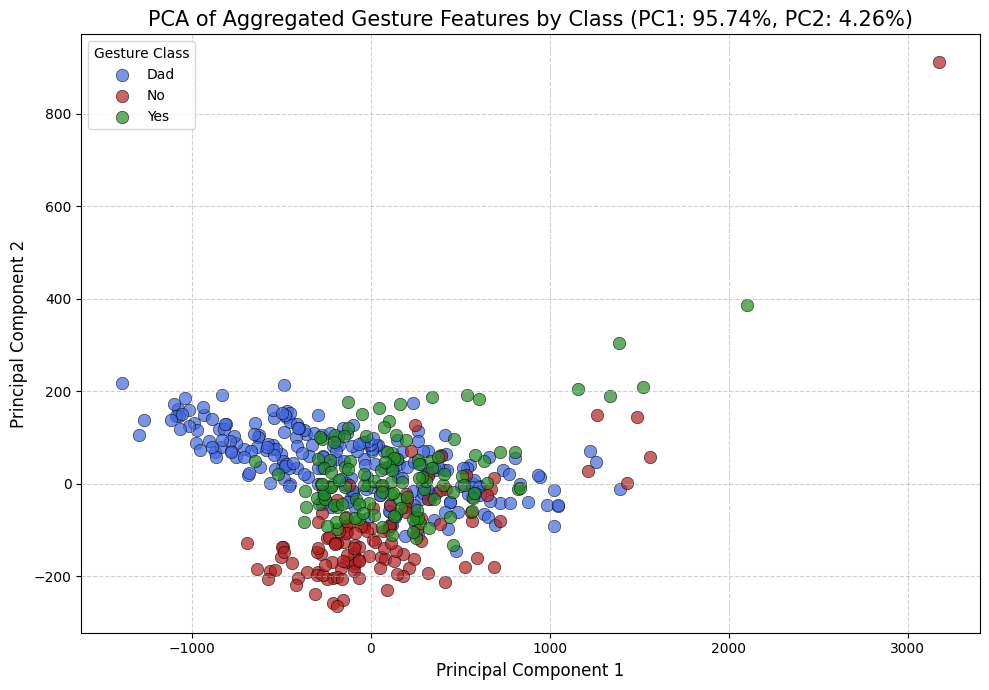

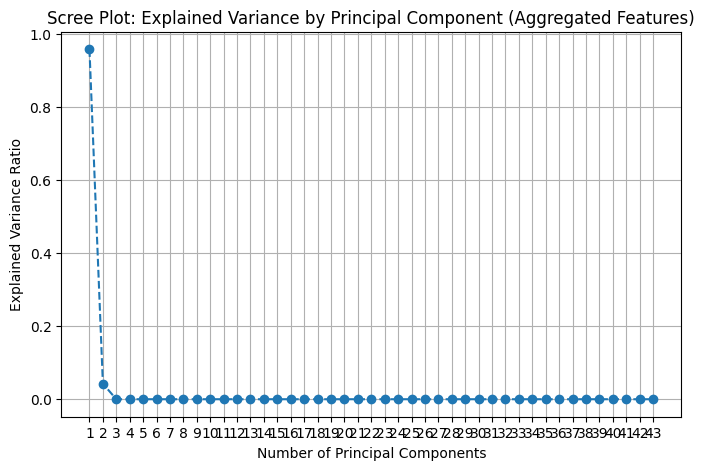

In [22]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load and clean data
CSV_FILE = 'coords_Sliding_Window_fram_Asmail1.csv'
try:
    df = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")
except FileNotFoundError:
    print(f"❌ File not found. Make sure '{CSV_FILE}' exists.")
    exit()

# Drop rows where class is NaN or not a string
df = df.dropna(subset=['class'])
df = df[df['class'].apply(lambda x: isinstance(x, str))]

# --- MODIFICATION START ---

# Identify feature columns (all columns except 'class', 'sequence_id', 'frame_id')
# We assume 'mfcc_1' onwards are features. A robust way is to select numerical columns
# and exclude the identifiers.
feature_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove 'sequence_id' and 'frame_id' if they are numeric and accidentally included
if 'sequence_id' in feature_columns:
    feature_columns.remove('sequence_id')
if 'frame_id' in feature_columns:
    feature_columns.remove('frame_id')

# Group by 'class' and 'sequence_id' and average the features for each gesture
# Each row in 'df_agg' will now represent a single gesture
df_agg = df.groupby(['class', 'sequence_id'])[feature_columns].mean().reset_index()

# Separate features (X_agg) and the main class labels (y_agg)
X_agg = df_agg[feature_columns].values
y_agg = df_agg['class'].values # We want to color by the main class (Yes, No, Dad)

# --- MODIFICATION END ---

# PCA on the aggregated (gesture-level) features
pca = PCA(n_components=2)
X_pca_agg = pca.fit_transform(X_agg)

# Get unique main class labels
unique_labels = np.unique(y_agg)

# Plotting
fig, ax = plt.subplots(figsize=(10, 7)) # Adjust figure size for better readability
fig.set_facecolor('white')
ax.set_facecolor('white')

# Use a specific colormap or define colors for few classes (Yes, No, Dad)
# If you only have 'Yes', 'No', 'Dad', you can assign specific colors:
color_map = {
    'Yes': 'forestgreen',
    'No': 'firebrick',
    'Dad': 'royalblue'
}
# Fallback for any other classes not in the map
fallback_colors = plt.cm.get_cmap('tab10', len(unique_labels))


# Plot each main class
for i, label in enumerate(unique_labels):
    idxs = np.where(y_agg == label)
    
    # Get color from the map or use a fallback from colormap
    color_to_use = color_map.get(label, fallback_colors(i))

    ax.scatter(
        X_pca_agg[idxs, 0],
        X_pca_agg[idxs, 1],
        label=label,
        alpha=0.7, # Transparency
        s=80,      # Larger marker size for gesture-level points
        color=color_to_use,
        edgecolors='black', # Add black outline for better contrast
        linewidths=0.5
    )

# Add Explained Variance Ratio to the title
explained_variance_ratio = pca.explained_variance_ratio_
title_suffix = f" (PC1: {explained_variance_ratio[0]*100:.2f}%, PC2: {explained_variance_ratio[1]*100:.2f}%)"
ax.set_title(f"PCA of Aggregated Gesture Features by Class{title_suffix}", fontsize=15)

ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)

ax.legend(title="Gesture Class", loc='best', fontsize=10) # Place legend in best location
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("pca_gestures_by_class.png", dpi=300)
plt.show()

# --- Optional: Scree Plot (explained variance) ---
# This scree plot will also be based on the aggregated features
if X_agg.shape[1] > 2:
    pca_full = PCA()
    pca_full.fit(X_agg)
    explained_variance = pca_full.explained_variance_ratio_

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
    plt.title("Scree Plot: Explained Variance by Principal Component (Aggregated Features)")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(True)
    plt.xticks(range(1, len(explained_variance) + 1))
    plt.savefig("scree_plot_aggregated_gestures.png", dpi=300)
    plt.show()

✅ CSV file loaded successfully.



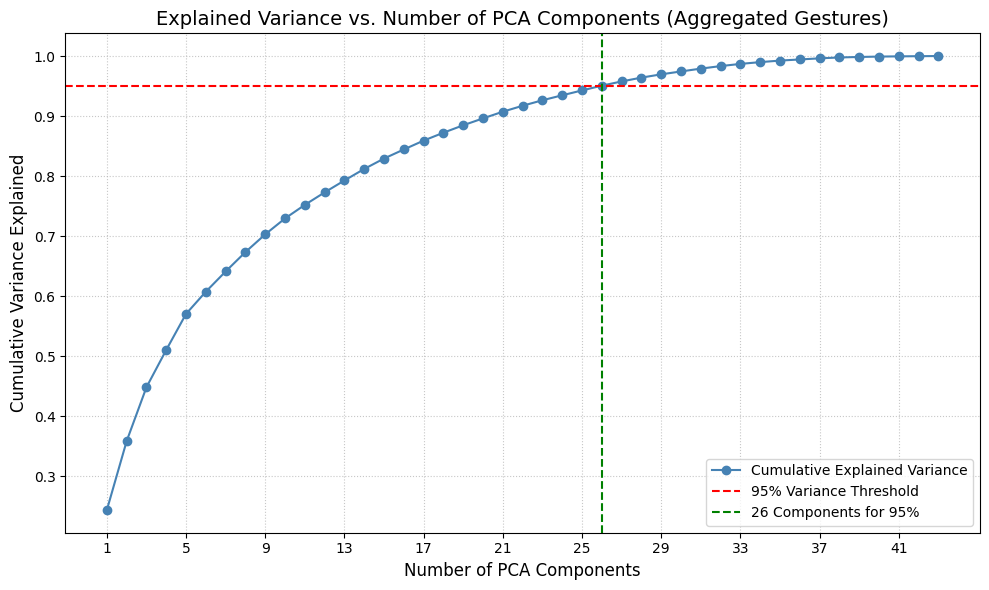

✅ To retain 95% of the variance in the aggregated gesture data, you need 26 PCA components.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load and clean dataset
CSV_FILE = "coords_Sliding_Window_fram_Asmail1.csv"
try:
    data = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")
except FileNotFoundError:
    print(f"❌ File not found. Make sure '{CSV_FILE}' exists.")
    exit()

# Drop rows where 'class' is NaN or not a string
data = data.dropna(subset=["class"])
data = data[data["class"].apply(lambda x: isinstance(x, str))]

# --- MODIFICATION START ---

# Identify feature columns: all numerical columns except 'sequence_id' and 'frame_id'.
# This approach is robust to changes in column order.
feature_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'sequence_id' in feature_columns:
    feature_columns.remove('sequence_id')
if 'frame_id' in feature_columns:
    feature_columns.remove('frame_id')

# Group by 'class' and 'sequence_id' and calculate the mean of features for each gesture.
# Each row in 'df_agg' now represents a single, complete gesture.
df_agg = data.groupby(['class', 'sequence_id'])[feature_columns].mean().reset_index()

# Separate features (X_agg) for PCA
X_agg = df_agg[feature_columns].values

# --- MODIFICATION END ---

# Standardize the aggregated features
scaler = StandardScaler()
X_scaled_agg = scaler.fit_transform(X_agg)

# Fit PCA with all components on the scaled aggregated data
pca_full = PCA(n_components=None)
pca_full.fit(X_scaled_agg)

# Calculate cumulative explained variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find the number of components to retain 95% of the variance
# np.argmax gives the first index where the condition is true.
# We add 1 because array indices are 0-based.
n_components_95 = np.argmax(cum_var >= 0.95) + 1

# Plotting the explained variance curve
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='-', color='steelblue', label='Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
# Adjust x-axis for the vertical line to correctly point to the component count
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components for 95%')

plt.xlabel("Number of PCA Components", fontsize=12)
plt.ylabel("Cumulative Variance Explained", fontsize=12)
plt.title("Explained Variance vs. Number of PCA Components (Aggregated Gestures)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(1, len(cum_var) + 1, max(1, len(cum_var) // 10))) # Dynamic x-ticks
plt.tight_layout()
plt.savefig("Explained_Variance_Aggregated_Gestures.png", dpi=300)
plt.show()

print(f"✅ To retain 95% of the variance in the aggregated gesture data, you need {n_components_95} PCA components.")
#

✅ CSV file loaded successfully.



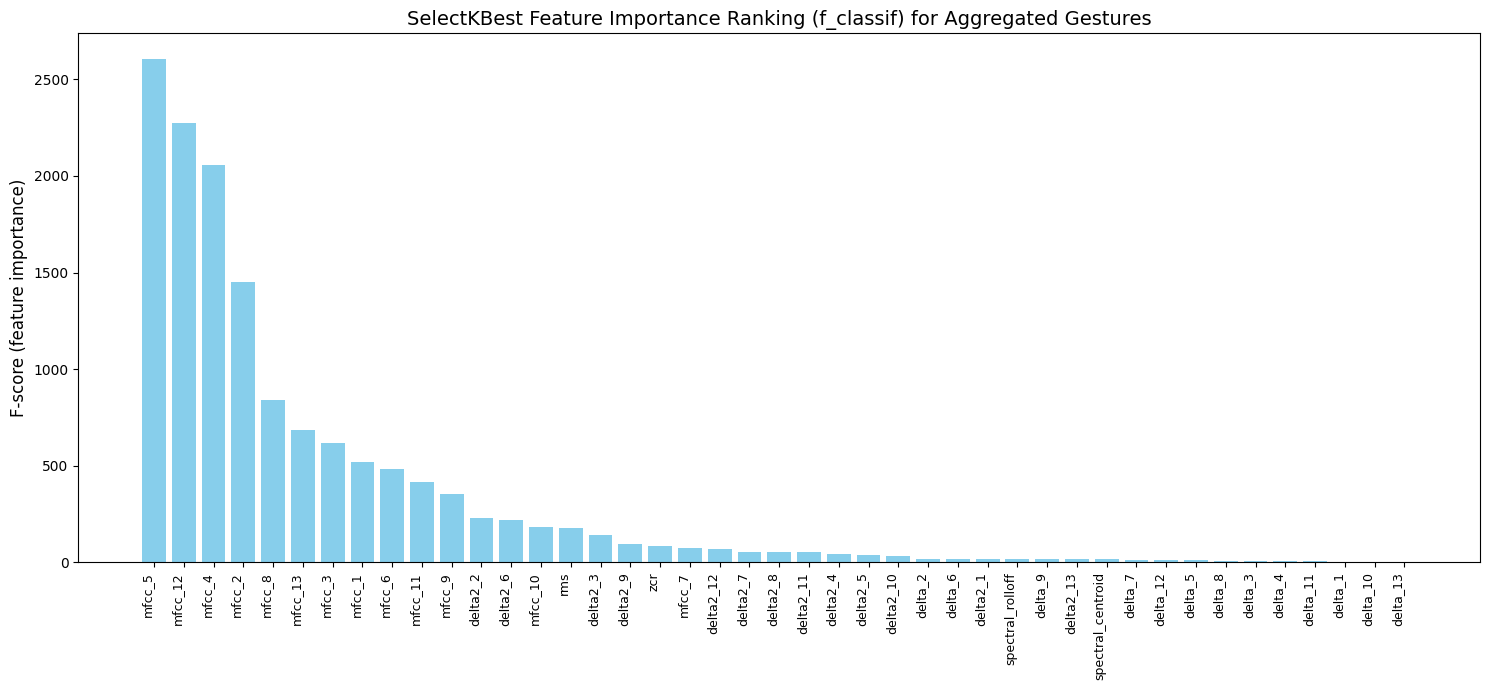

🔝 Most informative features for distinguishing aggregated gestures:
1. mfcc_5 - F-score: 2608.18
2. mfcc_12 - F-score: 2273.86
3. mfcc_4 - F-score: 2055.38
4. mfcc_2 - F-score: 1450.01
5. mfcc_8 - F-score: 839.30
6. mfcc_13 - F-score: 683.89
7. mfcc_3 - F-score: 617.52
8. mfcc_1 - F-score: 516.81
9. mfcc_6 - F-score: 481.94
10. mfcc_11 - F-score: 414.41
11. mfcc_9 - F-score: 354.35
12. delta2_2 - F-score: 226.94
13. delta2_6 - F-score: 216.64
14. mfcc_10 - F-score: 180.67
15. rms - F-score: 175.41
16. delta2_3 - F-score: 142.58
17. delta2_9 - F-score: 93.78
18. zcr - F-score: 81.64
19. mfcc_7 - F-score: 74.54
20. delta2_12 - F-score: 67.67
21. delta2_7 - F-score: 53.82
22. delta2_8 - F-score: 52.90
23. delta2_11 - F-score: 50.29
24. delta2_4 - F-score: 41.12
25. delta2_5 - F-score: 36.09
26. delta2_10 - F-score: 31.72
27. delta_2 - F-score: 18.83
28. delta_6 - F-score: 18.35
29. delta2_1 - F-score: 16.68
30. spectral_rolloff - F-score: 15.70
31. delta_9 - F-score: 14.88
32. delta2_13 -

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif

# Load and clean dataset
CSV_FILE = "coords_Sliding_Window_fram_Asmail1.csv"
try:
    data = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")
except FileNotFoundError:
    print(f"❌ File not found. Make sure '{CSV_FILE}' exists.")
    exit()

# Drop rows where 'class' is NaN or not a string
data = data.dropna(subset=["class"])
data = data[data["class"].apply(lambda x: isinstance(x, str))]

# --- MODIFICATION START ---

# Identify feature columns: all numerical columns except 'sequence_id' and 'frame_id'.
feature_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'sequence_id' in feature_columns:
    feature_columns.remove('sequence_id')
if 'frame_id' in feature_columns:
    feature_columns.remove('frame_id')

# Group by 'class' and 'sequence_id' and calculate the mean of features for each gesture.
# Each row in 'df_agg' now represents a single, complete gesture.
df_agg = data.groupby(['class', 'sequence_id'])[feature_columns].mean().reset_index()

# Extract the aggregated features (X_agg) and the corresponding class labels (y_agg_class)
# We use the main class for labeling, as the goal is to find features
# that differentiate between 'Yes', 'No', 'Dad' at the gesture level.
X_agg = df_agg[feature_columns].values
y_agg_class = df_agg['class'].values

# --- MODIFICATION END ---

# Encode class labels (using the main class labels from aggregated data)
le = LabelEncoder()
y_encoded_agg = le.fit_transform(y_agg_class)

# Scale features (using the aggregated features)
scaler = StandardScaler()
X_scaled_agg = scaler.fit_transform(X_agg)

# Apply SelectKBest with all features on the scaled aggregated data
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled_agg, y_encoded_agg)

# Get scores
scores = selector.scores_
# Feature names are from the original 'feature_columns' list
feature_names = np.array(feature_columns)

# Sort features by score
sorted_indices = np.argsort(scores)[::-1]
sorted_scores = scores[sorted_indices]
sorted_features = feature_names[sorted_indices]

# Plot scores
plt.figure(figsize=(15, 7), facecolor='white') # Increased figure size for more labels
plt.bar(range(len(sorted_scores)), sorted_scores, tick_label=sorted_features, color='skyblue')
plt.xticks(rotation=90, ha='right', fontsize=9) # Rotate labels, align right
plt.ylabel("F-score (feature importance)", fontsize=12)
plt.title("SelectKBest Feature Importance Ranking (f_classif) for Aggregated Gestures", fontsize=14)
plt.tight_layout()
plt.savefig("SelectKBest_Feature_Importance_Aggregated_Gestures.png", dpi=300)

plt.show()

# Print top features (adjusting the number to 43 as in your original request,
# or you can limit to top 10 if preferred for brevity)
print("🔝 Most informative features for distinguishing aggregated gestures:")
# Iterate through all 43 features if that's the desired output, or cap at a reasonable number
num_features_to_print = min(43, len(sorted_features)) # Ensure we don't try to print more than available
for i in range(num_features_to_print):
    print(f"{i+1}. {sorted_features[i]} - F-score: {sorted_scores[i]:.2f}")

✅ CSV file loaded successfully.

✅ PCA-reduced dataset saved to 'coords_audio_gesture_pca_reduced.csv'
   Shape of reduced data: (479, 28)
   Number of PCA components used for 95% variance: 26


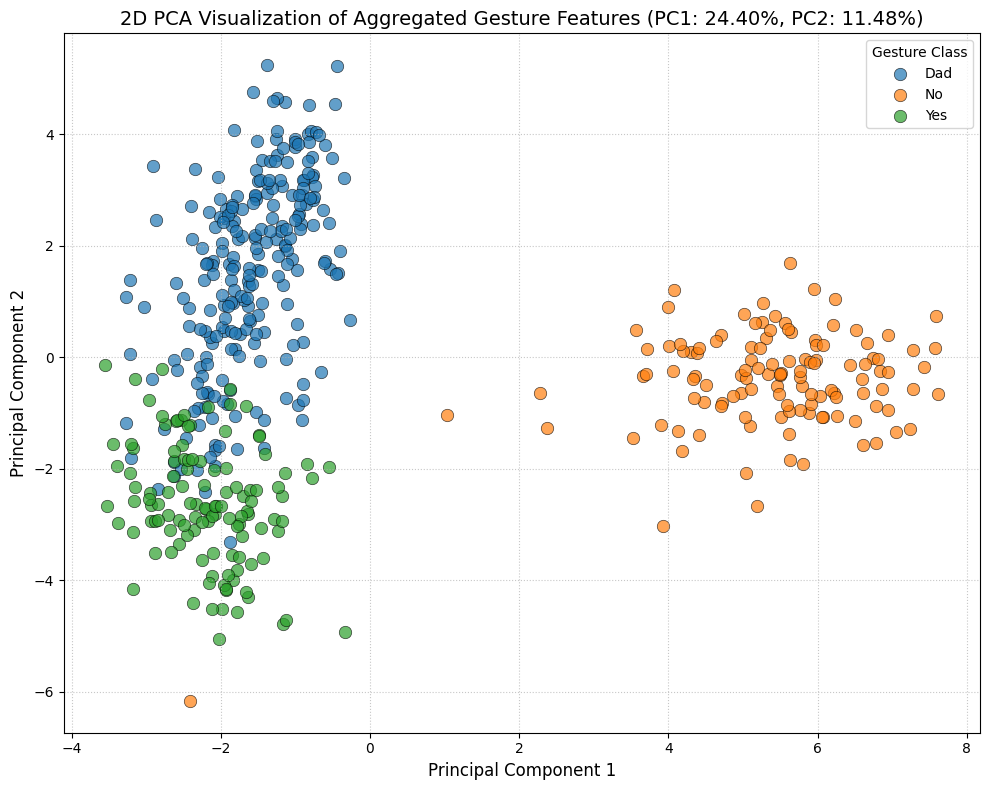

✅ Number of PCA components needed to retain 95% of variance (for aggregated gestures): 26


In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import joblib # For saving/loading models

# Load and clean dataset
CSV_FILE = "coords_Sliding_Window_fram_Asmail1.csv"
try:
    data = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")
except FileNotFoundError:
    print(f"❌ File not found. Make sure '{CSV_FILE}' exists.")
    exit()

# Drop rows where 'class' is NaN or not a string
data = data.dropna(subset=["class"])
data = data[data["class"].apply(lambda x: isinstance(x, str))]

# --- MODIFICATION START ---

# Identify feature columns: all numerical columns except 'sequence_id' and 'frame_id'.
feature_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'sequence_id' in feature_columns:
    feature_columns.remove('sequence_id')
if 'frame_id' in feature_columns:
    feature_columns.remove('frame_id')

# Group by 'class' and 'sequence_id' and calculate the mean of features for each gesture.
# Each row in 'df_agg' now represents a single, complete gesture.
df_agg = data.groupby(['class', 'sequence_id'])[feature_columns].mean().reset_index()

# Separate aggregated features (X_agg) and the corresponding class labels (y_agg_class)
# We also need the full gesture ID for saving the reduced dataset.
X_agg = df_agg[feature_columns].values
y_agg_class = df_agg['class'].values # Main class for general labeling
y_agg_gesture_id = df_agg['class'] + '_' + df_agg['sequence_id'].astype(str) # Full gesture ID

# --- MODIFICATION END ---

# Encode class labels (using the main class labels from aggregated data)
le = LabelEncoder()
y_encoded_agg = le.fit_transform(y_agg_class)
joblib.dump(le, "label_encoder_audio_gesture_pca.pkl") # Renamed pickle file

# Standardize aggregated features
scaler = StandardScaler()
X_scaled_agg = scaler.fit_transform(X_agg)
joblib.dump(scaler, "scaler_audio_gesture_pca.pkl") # Renamed pickle file

# Apply PCA to retain 95% variance on aggregated features
pca = PCA(n_components=0.95)
X_pca_agg = pca.fit_transform(X_scaled_agg)
joblib.dump(pca, "pca_audio_gesture.pkl") # Renamed pickle file

# Save PCA-reduced dataset (now at gesture level)
df_pca_agg = pd.DataFrame(X_pca_agg, columns=[f"pca_{i+1}" for i in range(X_pca_agg.shape[1])])
# Insert the original class and the full gesture_id for context
df_pca_agg.insert(0, "class", y_agg_class)
df_pca_agg.insert(1, "gesture_id", y_agg_gesture_id) # Add the combined gesture ID
df_pca_agg.to_csv("coords_audio_gesture_pca_reduced.csv", index=False) # Renamed output file

print(f"✅ PCA-reduced dataset saved to 'coords_audio_gesture_pca_reduced.csv'")
print(f"   Shape of reduced data: {df_pca_agg.shape}")
print(f"   Number of PCA components used for 95% variance: {X_pca_agg.shape[1]}")


# Optional: Visualize 2D PCA projection of aggregated gestures
pca_vis = PCA(n_components=2)
X_vis_agg = pca_vis.fit_transform(X_scaled_agg) # Fit on aggregated and scaled data

plt.figure(figsize=(10, 8), facecolor='white')
# Plot by main class (Yes, No, Dad)
for label in np.unique(y_agg_class): # Use y_agg_class for labels here
    idxs = np.where(y_agg_class == label)
    plt.scatter(
        X_vis_agg[idxs, 0],
        X_vis_agg[idxs, 1],
        label=label,
        alpha=0.7,
        s=80, # Larger marker size as each point is a gesture
        edgecolors='black',
        linewidths=0.5
    )

explained_variance_ratio_vis = pca_vis.explained_variance_ratio_
title_suffix_vis = f" (PC1: {explained_variance_ratio_vis[0]*100:.2f}%, PC2: {explained_variance_ratio_vis[1]*100:.2f}%)"
plt.title(f"2D PCA Visualization of Aggregated Gesture Features{title_suffix_vis}", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title="Gesture Class", loc='best', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("2D_PCA_Visualization_Aggregated_Gestures.png", dpi=300) # Renamed output file

plt.show()

print(f"✅ Number of PCA components needed to retain 95% of variance (for aggregated gestures): {pca.n_components_}")
#

✅ CSV file loaded successfully.

✅ SelectKBest-reduced dataset saved to 'coords_audio_gesture_kbest_reduced.csv'
   Shape of reduced data: (479, 16)
   Number of features selected: 14


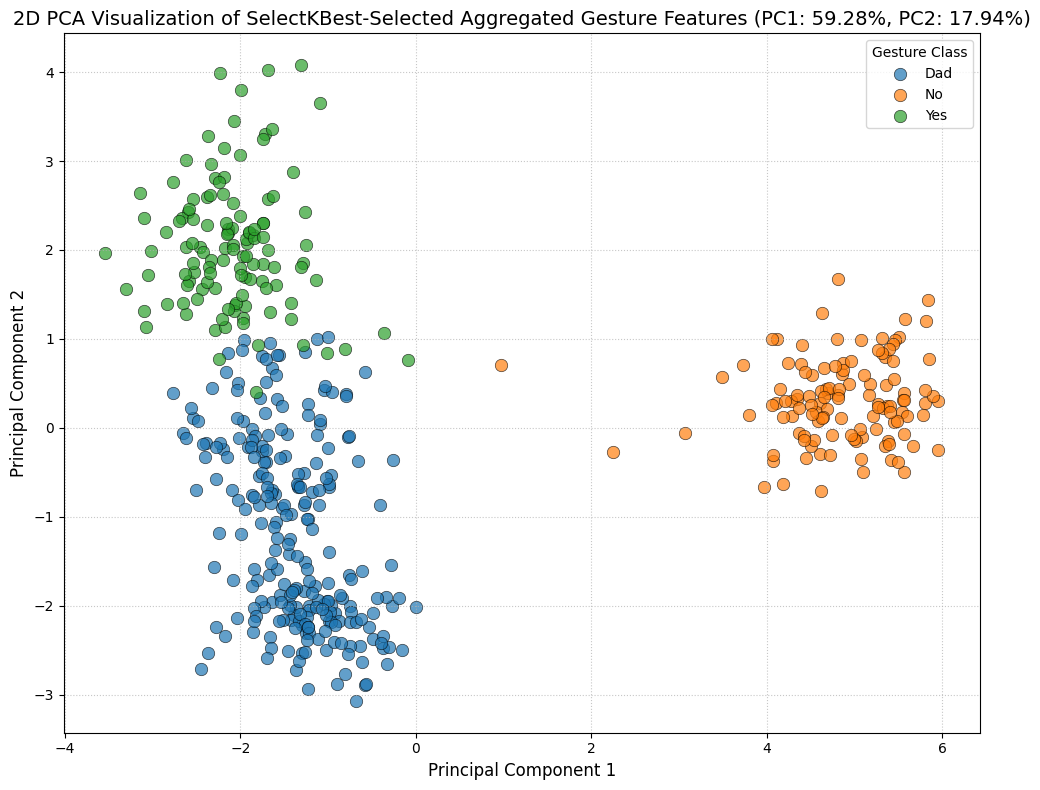

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA # Import PCA for visualization
import joblib

# Load and clean dataset
CSV_FILE = "coords_Sliding_Window_fram_Asmail1.csv"
try:
    data = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")
except FileNotFoundError:
    print(f"❌ File not found. Make sure '{CSV_FILE}' exists.")
    exit()

# Drop rows where 'class' is NaN or not a string
data = data.dropna(subset=["class"])
data = data[data["class"].apply(lambda x: isinstance(x, str))]

# --- MODIFICATION START ---

# Identify feature columns: all numerical columns except 'sequence_id' and 'frame_id'.
feature_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'sequence_id' in feature_columns:
    feature_columns.remove('sequence_id')
if 'frame_id' in feature_columns:
    feature_columns.remove('frame_id')

# Group by 'class' and 'sequence_id' and calculate the mean of features for each gesture.
# Each row in 'df_agg' now represents a single, complete gesture.
df_agg = data.groupby(['class', 'sequence_id'])[feature_columns].mean().reset_index()

# Extract the aggregated features (X_agg) and the corresponding class labels (y_agg_class)
X_agg = df_agg[feature_columns].values
y_agg_class = df_agg['class'].values # Main class for labeling
y_agg_gesture_id = df_agg['class'] + '_' + df_agg['sequence_id'].astype(str) # Full gesture ID for output CSV

# --- MODIFICATION END ---

# Encode class labels (using the main class labels from aggregated data)
le = LabelEncoder()
y_encoded_agg = le.fit_transform(y_agg_class)
joblib.dump(le, "label_encoder_audio_gesture_kbest.pkl") # Renamed pickle file

# Scale aggregated features
scaler = StandardScaler()
X_scaled_agg = scaler.fit_transform(X_agg)
joblib.dump(scaler, "scaler_audio_gesture_kbest.pkl") # Renamed pickle file

# Apply SelectKBest with k=14 on the scaled aggregated data
selector = SelectKBest(score_func=f_classif, k=14)
X_selected_agg = selector.fit_transform(X_scaled_agg, y_encoded_agg)
joblib.dump(selector, "selector_audio_gesture_kbest.pkl") # Renamed pickle file

# Save reduced dataset (at the gesture level)
df_selected_agg = pd.DataFrame(X_selected_agg, columns=[f"selected_feature_{i+1}" for i in range(X_selected_agg.shape[1])])
# Insert the original class and the full gesture_id for context
df_selected_agg.insert(0, "class", y_agg_class)
df_selected_agg.insert(1, "gesture_id", y_agg_gesture_id)
df_selected_agg.to_csv("coords_audio_gesture_kbest_reduced.csv", index=False) # Renamed output file

print(f"✅ SelectKBest-reduced dataset saved to 'coords_audio_gesture_kbest_reduced.csv'")
print(f"   Shape of reduced data: {df_selected_agg.shape}")
print(f"   Number of features selected: {X_selected_agg.shape[1]}")

# --- Visualization of Selected Gesture Features --- # This line was the cause of the error. It's now commented.

# Fit PCA on the X_selected_agg data to get 2 components for visualization
pca_vis = PCA(n_components=2)
X_vis_agg = pca_vis.fit_transform(X_selected_agg)

# Plot the 2D PCA projection of the selected features (from aggregated gestures)
plt.figure(figsize=(10, 8), facecolor='white')
# Plot by main class (Yes, No, Dad)
for label in np.unique(y_agg_class): # Use y_agg_class for labels here
    idxs = np.where(y_agg_class == label)
    plt.scatter(
        X_vis_agg[idxs, 0],
        X_vis_agg[idxs, 1],
        label=label,
        alpha=0.7,
        s=80, # Larger marker size as each point is a gesture
        edgecolors='black',
        linewidths=0.5
    )

explained_variance_ratio_vis = pca_vis.explained_variance_ratio_
title_suffix_vis = f" (PC1: {explained_variance_ratio_vis[0]*100:.2f}%, PC2: {explained_variance_ratio_vis[1]*100:.2f}%)"
plt.title(f"2D PCA Visualization of SelectKBest-Selected Aggregated Gesture Features{title_suffix_vis}", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend(title="Gesture Class", loc='best', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("2D_PCA_Visualization_KBest_Aggregated_Gestures.png", dpi=300) # Renamed output file

plt.show()
#
#

In [27]:
import pandas as pd
import numpy as np
import joblib

# === Load original frame-level data ===
CSV_FILE = "coords_Sliding_Window_fram_Asmail1.csv"
try:
    df = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.")
except FileNotFoundError:
    print(f"❌ File not found: {CSV_FILE}")
    exit()

# === Drop missing or malformed labels ===
df = df.dropna(subset=["class"])
df = df[df["class"].apply(lambda x: isinstance(x, str))]

# === Load SelectKBest model ===
selector = joblib.load("selector_audio_gesture_kbest.pkl")

# === Identify feature columns ===
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['sequence_id', 'frame_id']:  # remove non-feature columns
    if col in feature_cols:
        feature_cols.remove(col)

# === Extract features and apply selector ===
X = df[feature_cols].values
X_selected = selector.transform(X)
selected_feature_names = [f"selected_feature_{i+1}" for i in range(X_selected.shape[1])]

# === Build new DataFrame with essential metadata and selected features ===
df_selected = pd.DataFrame(X_selected, columns=selected_feature_names)
df_selected.insert(0, "frame_id", df["frame_id"].values)
df_selected.insert(0, "sequence_id", df["sequence_id"].values)
df_selected.insert(0, "class", df["class"].values)

# === Save to new CSV ===
df_selected.to_csv("coords_audio_frame_kbest.csv", index=False)
print("✅ New CSV saved: coords_audio_frame_kbest.csv")
print(f"   Shape: {df_selected.shape}")
#

#

✅ CSV file loaded successfully.
✅ New CSV saved: coords_audio_frame_kbest.csv
   Shape: (2874, 17)


In [28]:
import pandas as pd

# Load CSV file
CSV_FILE = 'coords_audio_frame_kbest.csv'

try:
    df = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")

    # Count the number of unique 'sequence_id' for each 'class'
    #print("📋 Number of unique gestures (sequence_id) per class:")
    #print(df.groupby('class')['sequence_id'].nunique())
    
    print("\n🧾 First 20 rows:")
    display(df.head(20)) # This will display the first 20 rows
    # Print all column names
    print("📋 Column Names:")
    print(df.columns.tolist())
    

except FileNotFoundError:
    print("❌ File not found. Make sure 'coords_Sliding_Window_fram.csv' exists.")

#

✅ CSV file loaded successfully.


🧾 First 20 rows:


,class,sequence_id,frame_id,selected_feature_1,selected_feature_2,selected_feature_3,selected_feature_4,selected_feature_5,selected_feature_6,selected_feature_7,selected_feature_8,selected_feature_9,selected_feature_10,selected_feature_11,selected_feature_12,selected_feature_13,selected_feature_14
0,Yes,0,0,-0.920778,0.827045,-0.216070,0.207367,-0.022384,0.000461,-0.124915,-0.020915,0.049378,-0.020628,0.030335,0.017190,-0.000007,-0.000289
1,Yes,0,1,-0.918717,0.828662,-0.205812,0.193754,-0.013925,0.004642,-0.132796,-0.017721,0.057649,-0.004574,0.026588,0.018541,-0.001068,-0.000385
2,Yes,0,2,-0.931158,0.829122,-0.204793,0.186547,-0.013345,0.013500,-0.135622,-0.010468,0.066585,-0.005567,0.025396,0.014053,0.000016,0.000145
3,Yes,0,3,-0.939063,0.826848,-0.221975,0.190530,-0.019892,0.016705,-0.140652,-0.008244,0.072054,0.003793,0.032117,0.012071,-0.001112,0.000933
4,Yes,0,4,-0.938823,0.827881,-0.231000,0.193994,-0.021173,0.019298,-0.142291,-0.002834,0.075497,0.007428,0.036194,0.009318,0.001149,0.000264
5,Yes,0,5,-0.938957,0.837803,-0.229921,0.200707,-0.019678,0.021113,-0.144022,-0.002018,0.075106,0.007648,0.037484,0.010151,0.000741,-0.000276
6,Yes,1,0,-0.910152,0.830573,-0.226482,0.174577,-0.016529,0.034904,-0.129493,-0.002178,0.084907,0.010168,0.033204,0.008423,-0.002626,-0.000477
7,Yes,1,1,-0.928053,0.811112,-0.210429,0.190631,-0.003862,0.021157,-0.118052,0.008124,0.078631,0.003425,0.030577,0.002630,0.000938,-0.000184
8,Yes,1,2,-0.923604,0.810412,-0.222530,0.214160,0.009436,0.007095,-0.108901,0.006728,0.068671,-0.005346,0.023826,-0.001930,-0.000188,0.000308
9,Yes,1,3,-0.911285,0.816059,-0.244715,0.230089,-0.002163,-0.000553,-0.099090,0.013213,0.063901,-0.009020,0.023800,-0.013457,-0.001125,0.000517


📋 Column Names:
['class', 'sequence_id', 'frame_id', 'selected_feature_1', 'selected_feature_2', 'selected_feature_3', 'selected_feature_4', 'selected_feature_5', 'selected_feature_6', 'selected_feature_7', 'selected_feature_8', 'selected_feature_9', 'selected_feature_10', 'selected_feature_11', 'selected_feature_12', 'selected_feature_13', 'selected_feature_14']


✅ CSV file loaded successfully.



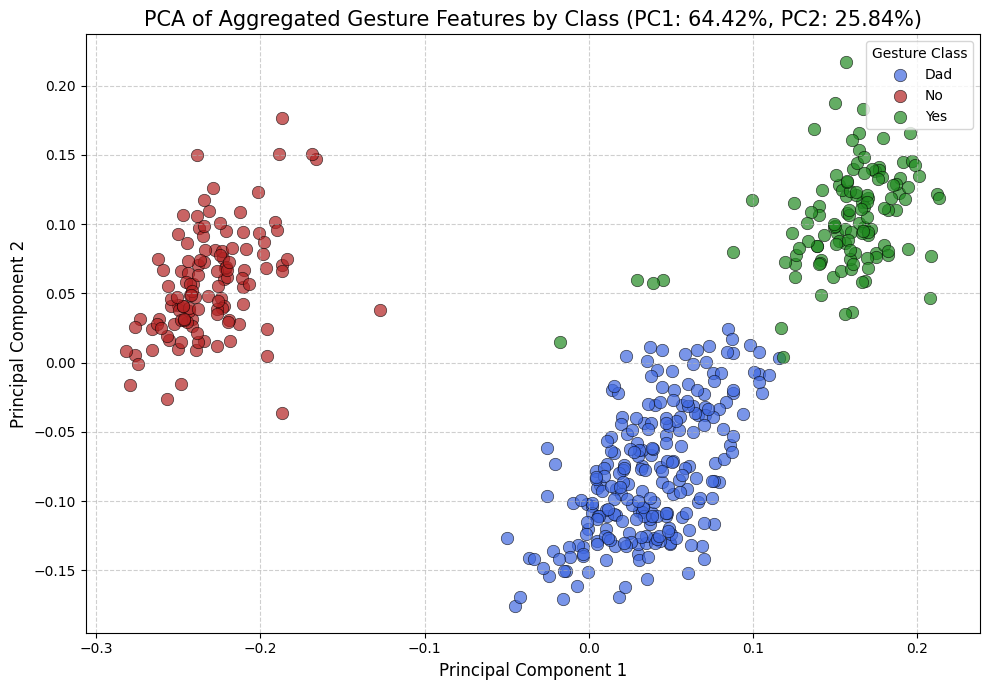

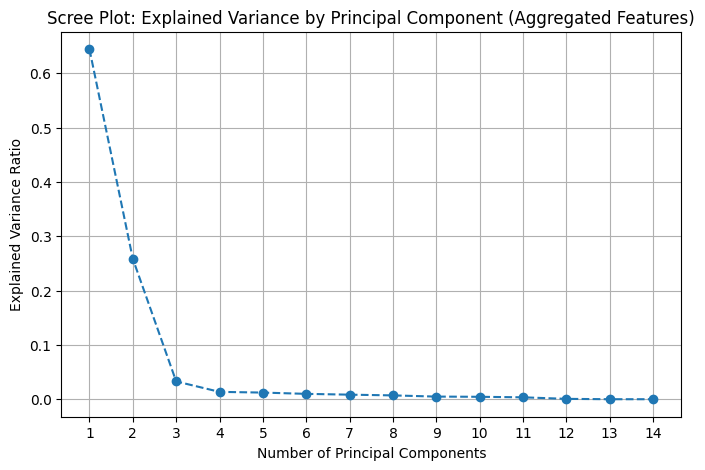

In [29]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load and clean data
CSV_FILE = 'coords_audio_frame_kbest.csv'
try:
    df = pd.read_csv(CSV_FILE)
    print("✅ CSV file loaded successfully.\n")
except FileNotFoundError:
    print(f"❌ File not found. Make sure '{CSV_FILE}' exists.")
    exit()

# Drop rows where class is NaN or not a string
df = df.dropna(subset=['class'])
df = df[df['class'].apply(lambda x: isinstance(x, str))]

# --- MODIFICATION START ---

# Identify feature columns (all columns except 'class', 'sequence_id', 'frame_id')
# We assume 'mfcc_1' onwards are features. A robust way is to select numerical columns
# and exclude the identifiers.
feature_columns = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove 'sequence_id' and 'frame_id' if they are numeric and accidentally included
if 'sequence_id' in feature_columns:
    feature_columns.remove('sequence_id')
if 'frame_id' in feature_columns:
    feature_columns.remove('frame_id')

# Group by 'class' and 'sequence_id' and average the features for each gesture
# Each row in 'df_agg' will now represent a single gesture
df_agg = df.groupby(['class', 'sequence_id'])[feature_columns].mean().reset_index()

# Separate features (X_agg) and the main class labels (y_agg)
X_agg = df_agg[feature_columns].values
y_agg = df_agg['class'].values # We want to color by the main class (Yes, No, Dad)

# --- MODIFICATION END ---

# PCA on the aggregated (gesture-level) features
pca = PCA(n_components=2)
X_pca_agg = pca.fit_transform(X_agg)

# Get unique main class labels
unique_labels = np.unique(y_agg)

# Plotting
fig, ax = plt.subplots(figsize=(10, 7)) # Adjust figure size for better readability
fig.set_facecolor('white')
ax.set_facecolor('white')

# Use a specific colormap or define colors for few classes (Yes, No, Dad)
# If you only have 'Yes', 'No', 'Dad', you can assign specific colors:
color_map = {
    'Yes': 'forestgreen',
    'No': 'firebrick',
    'Dad': 'royalblue'
}
# Fallback for any other classes not in the map
fallback_colors = plt.cm.get_cmap('tab10', len(unique_labels))


# Plot each main class
for i, label in enumerate(unique_labels):
    idxs = np.where(y_agg == label)
    
    # Get color from the map or use a fallback from colormap
    color_to_use = color_map.get(label, fallback_colors(i))

    ax.scatter(
        X_pca_agg[idxs, 0],
        X_pca_agg[idxs, 1],
        label=label,
        alpha=0.7, # Transparency
        s=80,      # Larger marker size for gesture-level points
        color=color_to_use,
        edgecolors='black', # Add black outline for better contrast
        linewidths=0.5
    )

# Add Explained Variance Ratio to the title
explained_variance_ratio = pca.explained_variance_ratio_
title_suffix = f" (PC1: {explained_variance_ratio[0]*100:.2f}%, PC2: {explained_variance_ratio[1]*100:.2f}%)"
ax.set_title(f"PCA of Aggregated Gesture Features by Class{title_suffix}", fontsize=15)

ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)

ax.legend(title="Gesture Class", loc='best', fontsize=10) # Place legend in best location
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("pca_gestures_by_class.png", dpi=300)
plt.show()

# --- Optional: Scree Plot (explained variance) ---
# This scree plot will also be based on the aggregated features
if X_agg.shape[1] > 2:
    pca_full = PCA()
    pca_full.fit(X_agg)
    explained_variance = pca_full.explained_variance_ratio_

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
    plt.title("Scree Plot: Explained Variance by Principal Component (Aggregated Features)")
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(True)
    plt.xticks(range(1, len(explained_variance) + 1))
    plt.savefig("scree_plot_aggregated_gestures.png", dpi=300)
    plt.show()


In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from sklearn.metrics import classification_report
import joblib

# Load the frame-level CSV
df = pd.read_csv("coords_audio_frame_kbest.csv")

# Check necessary columns
required_columns = {'class', 'sequence_id'}
if not required_columns.issubset(df.columns):
    raise ValueError("Missing required columns: 'class' and 'sequence_id'")

# Group by 'class' and 'sequence_id' to form gestures (sequence of frames)
gesture_groups = df.groupby(['class', 'sequence_id'])

# Prepare sequences
sequences = []
labels = []
max_timesteps = max(len(g) for _, g in gesture_groups)

for (cls, seq_id), group in gesture_groups:
    features = group.drop(columns=['class', 'sequence_id', 'frame_id'], errors='ignore').values
    # Pad sequence to match max length
    padded = np.pad(features, ((0, max_timesteps - len(features)), (0, 0)), mode='constant')
    sequences.append(padded)
    labels.append(cls)

X = np.array(sequences)  # shape: (samples, timesteps, features)
print(f"✅ Shape of input data: {X.shape}")

# Encode class labels
le = LabelEncoder()
y = le.fit_transform(labels)
joblib.dump(le, "label_encoder_audio_frame_lstm.pkl")

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential([
    Masking(mask_value=0.0, input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y)), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

# Save model
model.save("audio_lstm_model.keras")

# Evaluate
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred_labels, target_names=le.classes_))
#

✅ Shape of input data: (479, 6, 14)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 6, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,403 (87.51 KB)

 Trainable params: 22,403 (87.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4019 - loss: 1.0718 - val_accuracy: 0.4896 - val_loss: 0.9855
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5172 - loss: 0.9250 - val_accuracy: 0.6875 - val_loss: 0.7833
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8397 - loss: 0.6646 - val_accuracy: 0.8125 - val_loss: 0.3892
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9449 - loss: 0.2943 - val_accuracy: 0.9792 - val_loss: 0.1151
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9637 - loss: 0.1013 - val_accuracy: 0.9792 - val_loss: 0.0571
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9506 - loss: 0.1128 - val_accuracy: 0.9896 - val_loss: 0.0591
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9742 - loss: 0.0697 - val_accuracy: 0.8958 - val_loss: 0.1805
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9702 - loss: 0.0673 - val_accuracy: 0.9792 - val_loss:

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


<Figure size 600x500 with 0 Axes>

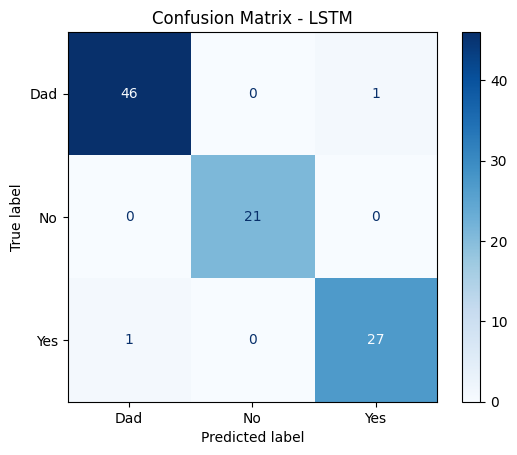

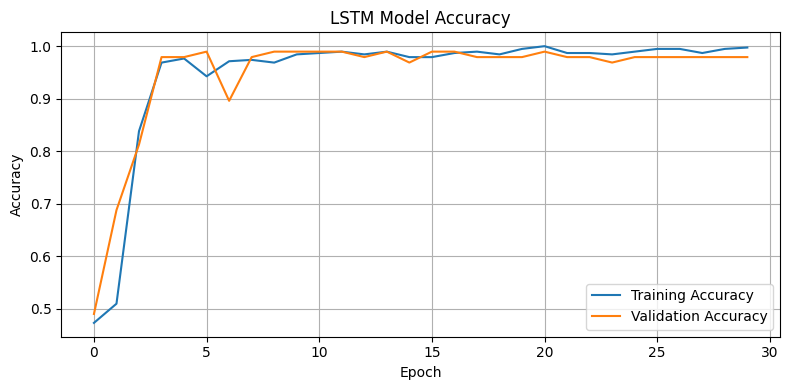

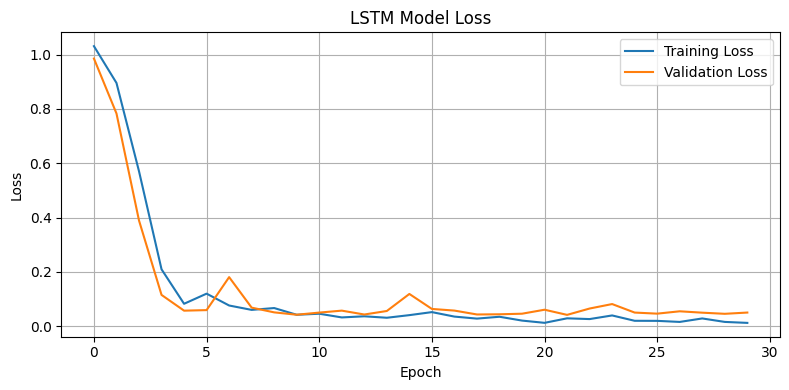

In [32]:
# Predict
y_pred_probs = model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)  # Convert softmax output to class indices

# Now run your plots
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - LSTM")
plt.grid(False)
plt.show()

# Accuracy Curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
import pandas as pd
df = pd.read_csv("coords_audio_frame_kbest.csv")
print(df["class"].value_counts())

class
Dad    1434
Yes     720
No      720
Name: count, dtype: int64


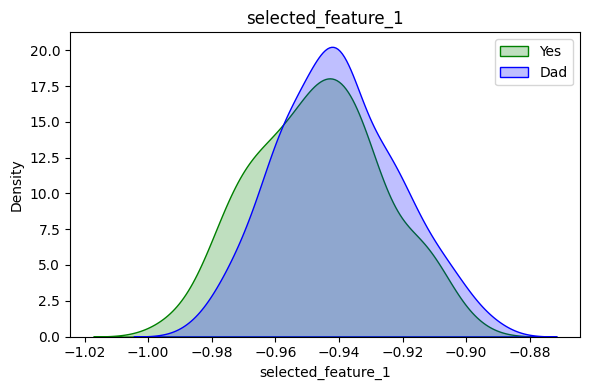

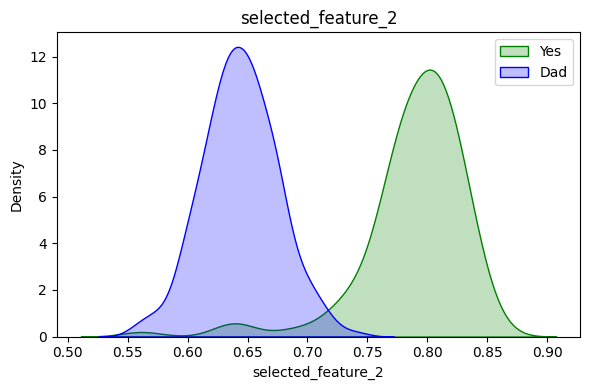

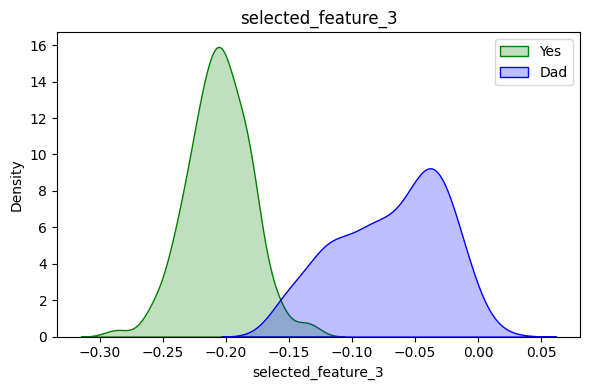

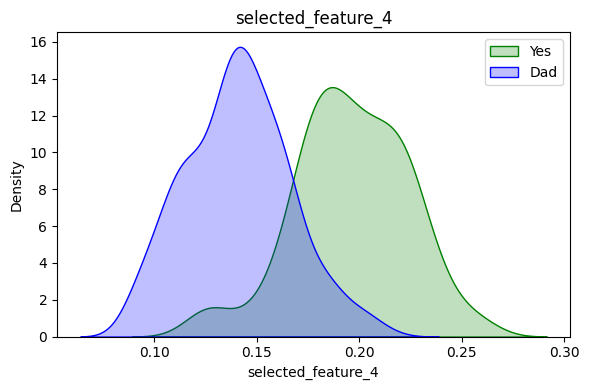

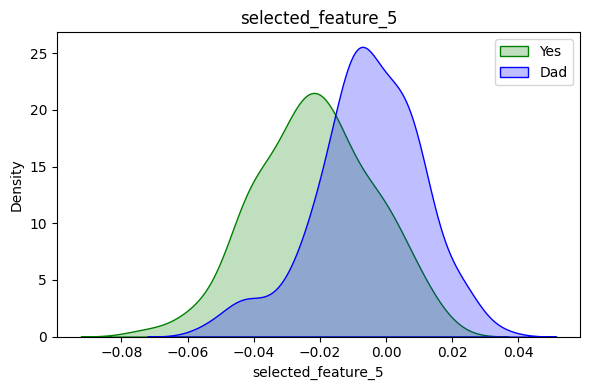

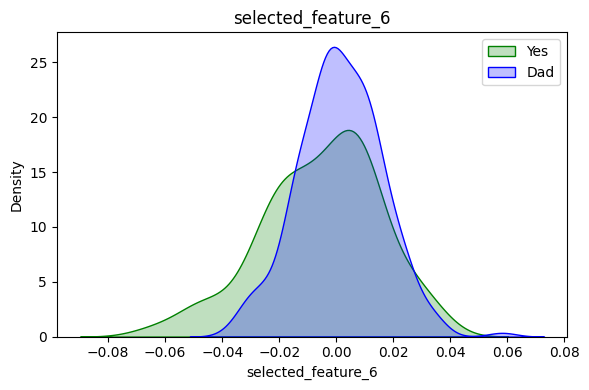

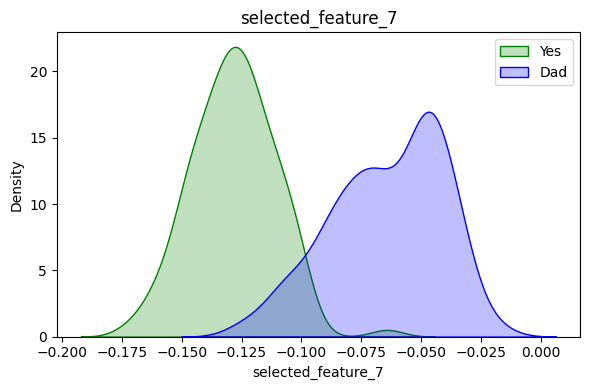

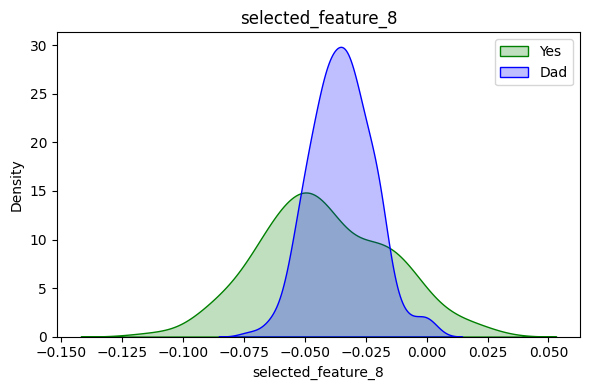

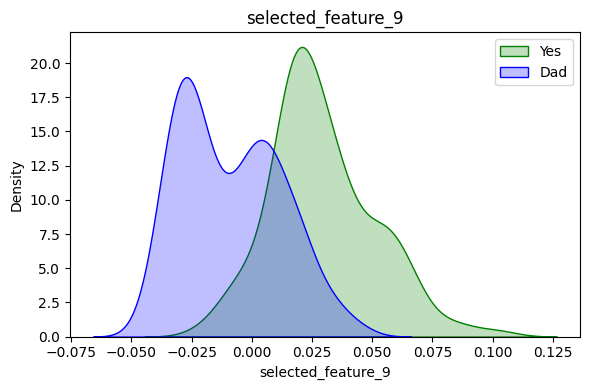

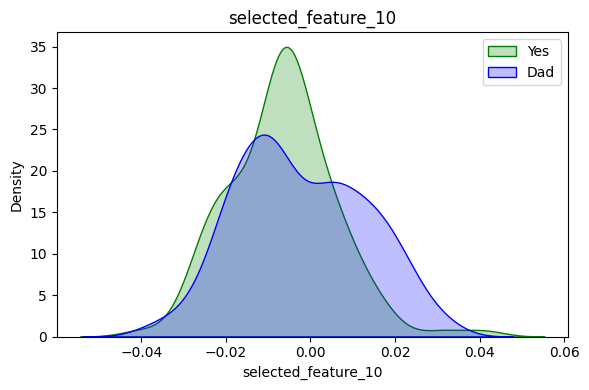

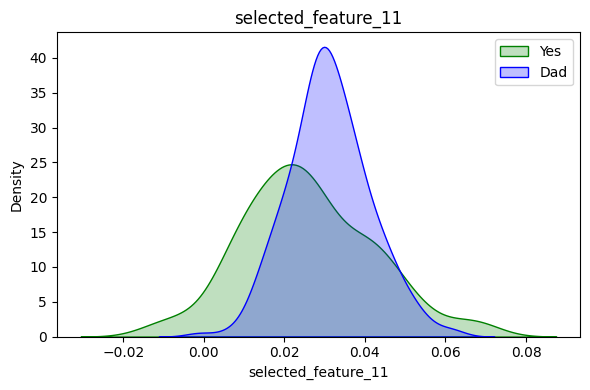

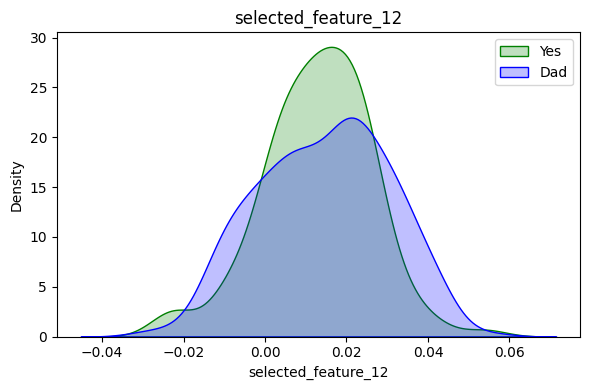

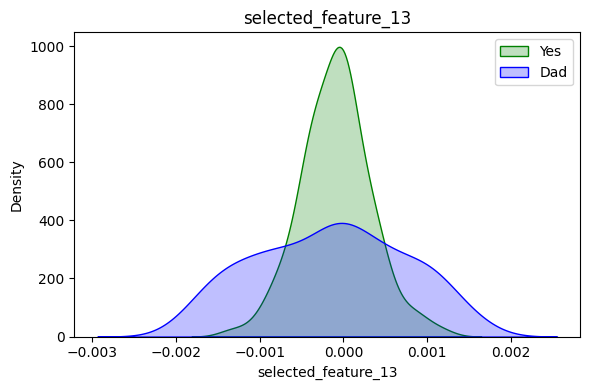

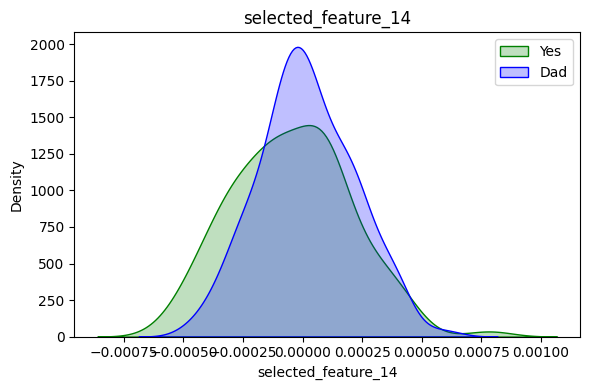

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the frame-level CSV (e.g., coords_audio_frame_kbest.csv)
df = pd.read_csv("coords_audio_frame_kbest.csv")

# Group by class and sequence_id to aggregate per gesture
df_gesture = df.groupby(['class', 'sequence_id']).mean().reset_index()

# Plot KDE distributions per gesture
for col in df_gesture.columns[3:]:  # skip 'class', 'sequence_id', and 'frame_id'
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df_gesture[df_gesture["class"]=="Yes"], x=col, label="Yes", fill=True, color='green')
    sns.kdeplot(data=df_gesture[df_gesture["class"]=="Dad"], x=col, label="Dad", fill=True, color='blue')
    plt.title(col)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"gesture_level_kde_{col}.png", dpi=300)
    plt.show()


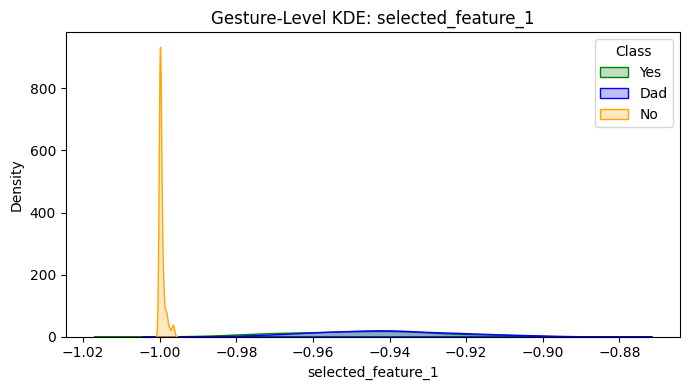

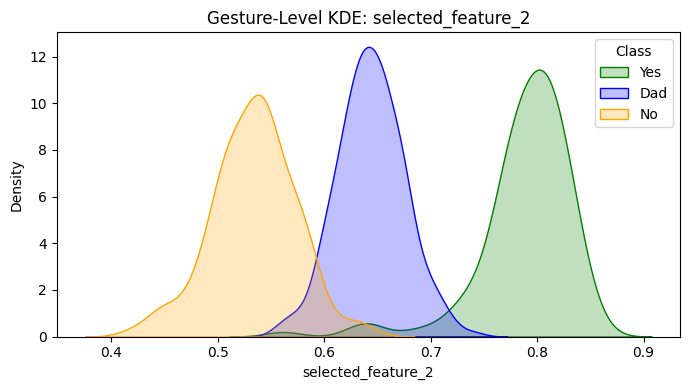

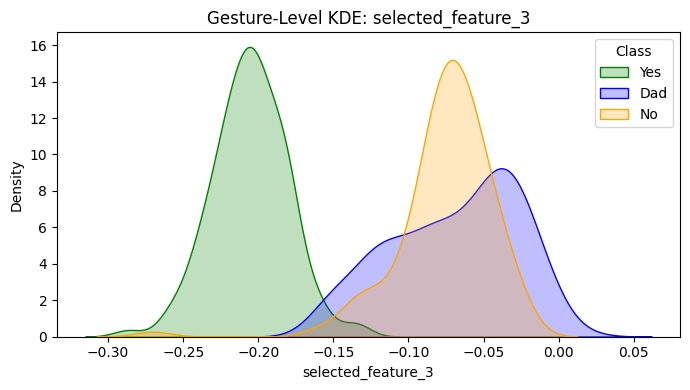

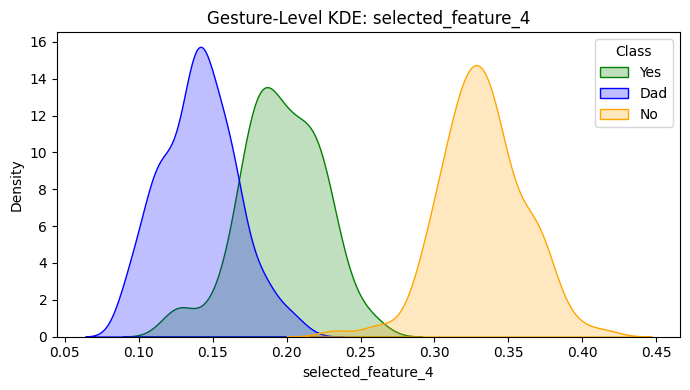

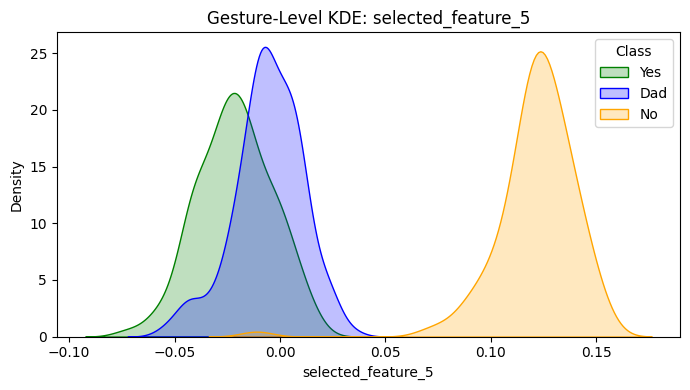

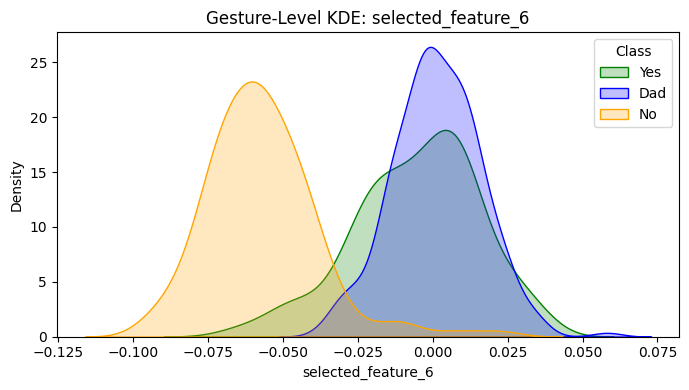

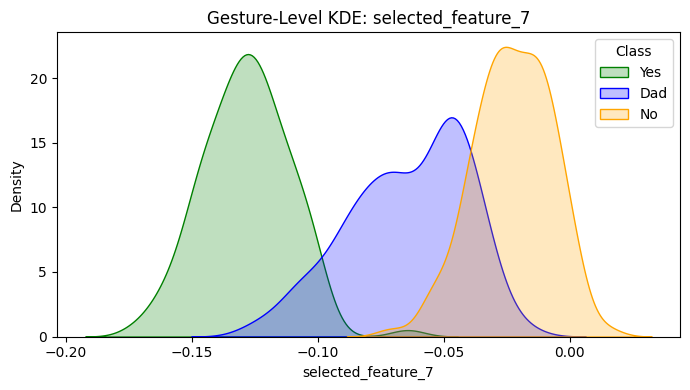

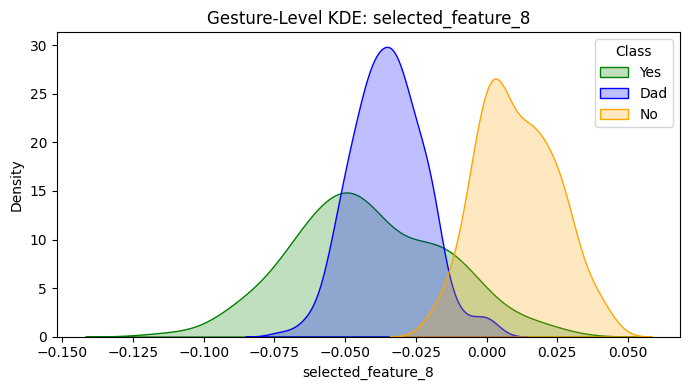

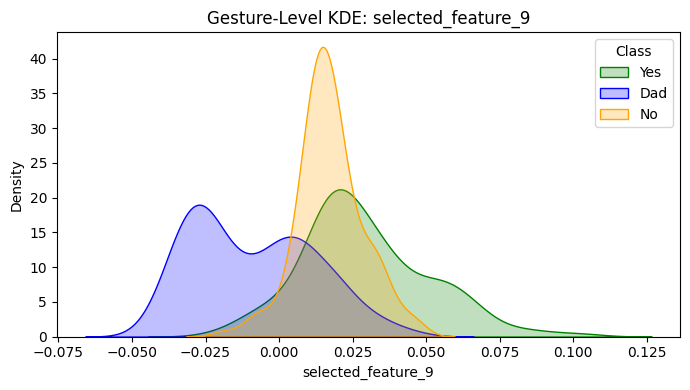

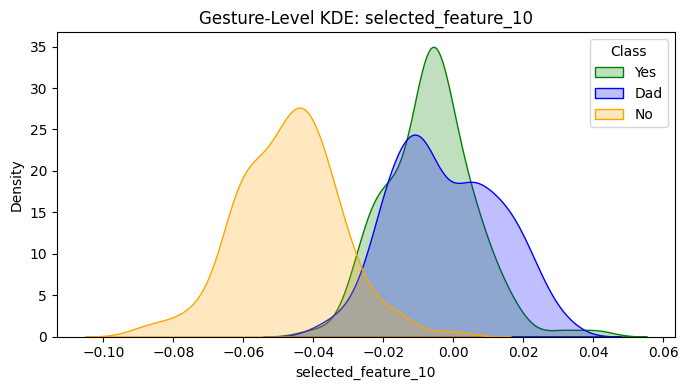

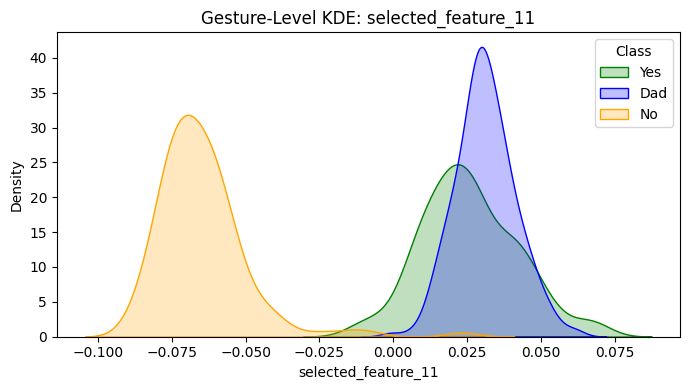

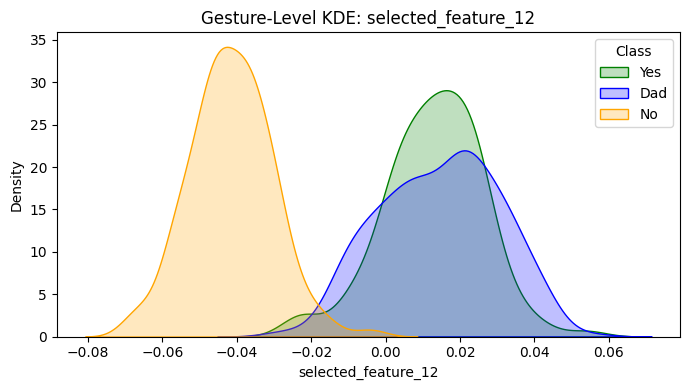

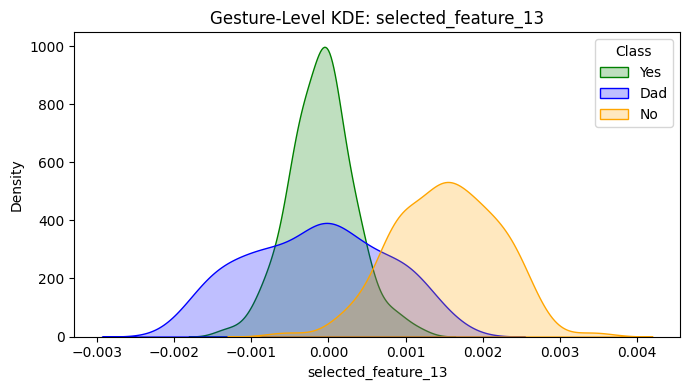

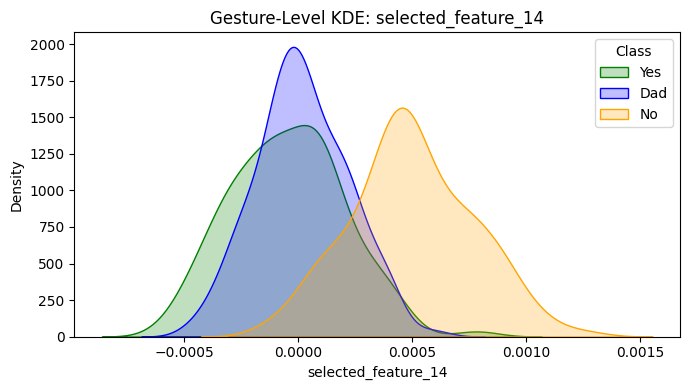

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the frame-level CSV
df = pd.read_csv("coords_audio_frame_kbest.csv")

# Aggregate per gesture (sequence)
df_gesture = df.groupby(['class', 'sequence_id']).mean().reset_index()

# Plot KDE for each selected feature across all gesture classes
for col in df_gesture.columns[3:]:  # Skip class, sequence_id, frame_id (if any)
    plt.figure(figsize=(7, 4))
    
    # KDE for each class
    sns.kdeplot(data=df_gesture[df_gesture["class"] == "Yes"], x=col, label="Yes", fill=True, color='green')
    sns.kdeplot(data=df_gesture[df_gesture["class"] == "Dad"], x=col, label="Dad", fill=True, color='blue')
    sns.kdeplot(data=df_gesture[df_gesture["class"] == "No"],  x=col, label="No", fill=True, color='orange')
    
    plt.title(f"Gesture-Level KDE: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend(title="Class")
    plt.tight_layout()
    plt.savefig(f"gesture_level_kde_{col}.png", dpi=300)
    plt.show()


In [36]:
import joblib

# Load the label encoder
le = joblib.load("label_encoder_audio_frame_lstm.pkl")

# Print the list of labels
print("List of labels:", le.classes_)

# If you want to see exactly how the numbers map to the names:
print("\n--- Label Mapping ---")
for index, label in enumerate(le.classes_):
    print(f"ID {index} -> {label}")

List of labels: ['Dad' 'No' 'Yes']

--- Label Mapping ---
ID 0 -> Dad
ID 1 -> No
ID 2 -> Yes


In [9]:
# ✅ Real-Time Inference for LSTM-Based Audio Gesture Classifier

import numpy as np
import pyaudio
import librosa
import joblib
import threading
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings("ignore")

# === Load Model and Tools ===
model = load_model("audio_lstm_model.keras")
scaler = joblib.load("scaler_audio_gesture_kbest.pkl")
selector = joblib.load("selector_audio_gesture_kbest.pkl")
le = joblib.load("label_encoder_audio_frame_lstm.pkl")
labels = le.classes_.tolist()

CONFIDENCE_THRESHOLD = 0.9

# === Audio Config ===
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000 
CHUNK = 1024
SEGMENT_DURATION = 1.0  # seconds
FRAMES_PER_SEGMENT = int(RATE * SEGMENT_DURATION)

# === Select Input Device ===
def get_valid_input_device():
    audio = pyaudio.PyAudio()
    
    DEVICE_TO_USE = 18 
    
    try:
        info = audio.get_device_info_by_index(DEVICE_TO_USE)
        if info["maxInputChannels"] >= 1:
            print(f"✅ Manually selecting device {DEVICE_TO_USE}: {info['name']}")
            return DEVICE_TO_USE
    except Exception:
        pass
        
    raise RuntimeError(f"❌ Failed to use device {DEVICE_TO_USE} or it has no input channels.")

DEVICE_ID = get_valid_input_device()

# === Classification Function ===
def classify_lstm_segment(audio_data):
    volume = np.mean(np.abs(audio_data))
    
    # Silence detection
    if volume < 0.05: 
        return "Silent", 0.65

    # === Sliding window over 1s segment ===
    WINDOW_DURATION = 0.5
    HOP_DURATION = 0.1
    win_size = int(RATE * WINDOW_DURATION)
    hop_len = int(RATE * HOP_DURATION)

    sequence = []
    for start in range(0, len(audio_data) - win_size + 1, hop_len):
        window = audio_data[start:start + win_size]

        # Feature extraction
        mfcc = librosa.feature.mfcc(y=window, sr=RATE, n_mfcc=13) 
        mfcc_cmvn = librosa.util.normalize(mfcc)
        delta = librosa.feature.delta(mfcc_cmvn)
        delta2 = librosa.feature.delta(mfcc_cmvn, order=2)
        spectral_centroid = librosa.feature.spectral_centroid(y=window, sr=RATE)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=window, sr=RATE)
        zcr = librosa.feature.zero_crossing_rate(y=window)
        rms = librosa.feature.rms(y=window)

        features = (
            np.mean(mfcc_cmvn, axis=1).tolist() +
            np.mean(delta, axis=1).tolist() +
            np.mean(delta2, axis=1).tolist() +
            [np.mean(spectral_centroid), np.mean(spectral_rolloff), np.mean(zcr), np.mean(rms)]
        )

        X_scaled = scaler.transform([features])
        X_selected = selector.transform(X_scaled)
        sequence.append(X_selected[0])

    sequence = np.array(sequence)
    max_len = model.input_shape[1]
    if len(sequence) < max_len:
        sequence = np.pad(sequence, ((0, max_len - len(sequence)), (0, 0)), mode='constant')
    else:
        sequence = sequence[:max_len]

    X_input = sequence.reshape(1, max_len, -1)
    
    # NEW: Added verbose=0 to stop console spam
    prediction = model.predict(X_input, verbose=0) 
    confidence = float(np.max(prediction))
    label_index = int(np.argmax(prediction))

    return ("Unknown", confidence) if confidence < CONFIDENCE_THRESHOLD else (labels[label_index], confidence)

# === Stream Setup ===
audio = pyaudio.PyAudio()
stream = audio.open(format=FORMAT, channels=CHANNELS, rate=RATE,
                    input=True, input_device_index=DEVICE_ID, frames_per_buffer=CHUNK)

stop_flag = False
audio_buffer = []

def listen_for_exit():
    global stop_flag
    while True:
        if input().strip().lower() == 'q':
            stop_flag = True
            break

threading.Thread(target=listen_for_exit, daemon=True).start()
print("🎤 Real-time LSTM gesture recognition running... Type 'q' + Enter to stop.")

try:
    while not stop_flag:
        data = stream.read(CHUNK, exception_on_overflow=False)
        audio_buffer.append(data)

        if len(audio_buffer) * CHUNK >= FRAMES_PER_SEGMENT:
            raw = np.frombuffer(b''.join(audio_buffer), dtype=np.int16).astype(np.float32) / 32768.0
            
            result, conf = classify_lstm_segment(raw)
            print(f"🔍 Predicted: {result} (Confidence: {conf:.2f} | Volume: {np.mean(np.abs(raw)):.4f})")
            
            # === CLEAR BUFFER ===
            audio_buffer = []

except Exception as e:
    print(f"⚠️ Error: {e}")
finally:
    stream.stop_stream()
    stream.close()
    audio.terminate()
    print("✅ Audio stream closed.")

✅ Manually selecting device 18: default
🎤 Real-time LSTM gesture recognition running... Type 'q' + Enter to stop.
🔍 Predicted: Silent (Confidence: 0.65 | Volume: 0.0092)
🔍 Predicted: Silent (Confidence: 0.65 | Volume: 0.0099)
🔍 Predicted: Silent (Confidence: 0.65 | Volume: 0.0098)
🔍 Predicted: Silent (Confidence: 0.65 | Volume: 0.0102)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0606)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0812)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0756)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0623)
🔍 Predicted: Unknown (Confidence: 0.43 | Volume: 0.0987)
🔍 Predicted: Unknown (Confidence: 0.67 | Volume: 0.1022)
🔍 Predicted: Dad (Confidence: 0.99 | Volume: 0.0884)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0898)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0938)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0825)
🔍 Predicted: Dad (Confidence: 1.00 | Volume: 0.0874)


 q


🔍 Predicted: Silent (Confidence: 0.65 | Volume: 0.0123)
✅ Audio stream closed.


In [8]:
#
# ✅ Real-Time Inference for LSTM-Based Audio Gesture Classifier

import numpy as np
import pyaudioq
import librosa
import joblib
import threading
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings("ignore")

# === Load Model and Tools ===
model = load_model("audio_lstm_model.keras")
scaler = joblib.load("scaler_audio_gesture_kbest.pkl")
selector = joblib.load("selector_audio_gesture_kbest.pkl")
le = joblib.load("label_encoder_audio_frame_lstm.pkl")
labels = le.classes_.tolist()

CONFIDENCE_THRESHOLD = 0.9

# === Audio Config ===
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000 # FIX: Reverted to 48000 to fix the OSError: Invalid sample rate
CHUNK = 1024
SEGMENT_DURATION = 1.0  # seconds
FRAMES_PER_SEGMENT = int(RATE * SEGMENT_DURATION)

# === Select Input Device ===
def get_valid_input_device():
    audio = pyaudio.PyAudio()
    
    # --- FIX: MANUAL DEVICE SELECTION (Using ID 6) ---
    DEVICE_TO_USE = 18 
    
    try:
        info = audio.get_device_info_by_index(DEVICE_TO_USE)
        if info["maxInputChannels"] >= 1:
            print(f"✅ Manually selecting device {DEVICE_TO_USE}: {info['name']}")
            return DEVICE_TO_USE
    except Exception:
        # Fallback error handling
        pass
        
    raise RuntimeError(f"❌ Failed to use device {DEVICE_TO_USE} or it has no input channels.")

DEVICE_ID = get_valid_input_device()

# === Classification Function ===
def classify_lstm_segment(audio_data):
    volume = np.mean(np.abs(audio_data))
    print(f"🔈 Volume: {volume:.6f}")
    
    # FIX: Kept the very low threshold (0.01 -> 0.0005)
    if volume < 0.04: 
        return "Silent", 0.65

    # === Sliding window over 1s segment ===
    WINDOW_DURATION = 0.5
    HOP_DURATION = 0.1
    win_size = int(RATE * WINDOW_DURATION)
    hop_len = int(RATE * HOP_DURATION)

    sequence = []
    for start in range(0, len(audio_data) - win_size + 1, hop_len):
        window = audio_data[start:start + win_size]

        # Feature extraction
        mfcc = librosa.feature.mfcc(y=window, sr=RATE, n_mfcc=13) 
        mfcc_cmvn = librosa.util.normalize(mfcc)
        delta = librosa.feature.delta(mfcc_cmvn)
        delta2 = librosa.feature.delta(mfcc_cmvn, order=2)
        spectral_centroid = librosa.feature.spectral_centroid(y=window, sr=RATE)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=window, sr=RATE)
        zcr = librosa.feature.zero_crossing_rate(y=window)
        rms = librosa.feature.rms(y=window)

        features = (
            np.mean(mfcc_cmvn, axis=1).tolist() +
            np.mean(delta, axis=1).tolist() +
            np.mean(delta2, axis=1).tolist() +
            [np.mean(spectral_centroid), np.mean(spectral_rolloff), np.mean(zcr), np.mean(rms)]
        )

        X_scaled = scaler.transform([features])
        X_selected = selector.transform(X_scaled)
        sequence.append(X_selected[0])

    sequence = np.array(sequence)
    max_len = model.input_shape[1]
    if len(sequence) < max_len:
        sequence = np.pad(sequence, ((0, max_len - len(sequence)), (0, 0)), mode='constant')
    else:
        sequence = sequence[:max_len]

    X_input = sequence.reshape(1, max_len, -1)
    prediction = model.predict(X_input)
    confidence = float(np.max(prediction))
    label_index = np.argmax(prediction)

    return ("Unknown", confidence) if confidence < CONFIDENCE_THRESHOLD else (labels[label_index], confidence)

# === Stream Setup ===
audio = pyaudio.PyAudio()
stream = audio.open(format=FORMAT, channels=CHANNELS, rate=RATE,
                    input=True, input_device_index=DEVICE_ID, frames_per_buffer=CHUNK)

stop_flag = False
audio_buffer = []

def listen_for_exit():
    global stop_flag
    while True:
        if input().strip().lower() == 'q':
            stop_flag = True
            break

threading.Thread(target=listen_for_exit, daemon=True).start()
print("🎤 Real-time LSTM gesture recognition running... Press 'q' + Enter to stop.")

try:
    while not stop_flag:
        data = stream.read(CHUNK, exception_on_overflow=False)
        audio_buffer.append(data)

        if len(audio_buffer) * CHUNK >= FRAMES_PER_SEGMENT:
            raw = np.frombuffer(b''.join(audio_buffer), dtype=np.int16).astype(np.float32) / 32768.0
            audio_buffer = []
            result, conf = classify_lstm_segment(raw)
            print(f"🔍 Predicted: {result} (Confidence: {conf:.2f})")

except Exception as e:
    print(f"⚠️ Error: {e}")
finally:
    stream.stop_stream()
    stream.close()
    audio.terminate()
    print("✅ Audio stream closed.")

✅ Manually selecting device 18: default
🎤 Real-time LSTM gesture recognition running... Press 'q' + Enter to stop.
🔈 Volume: 0.010747
🔍 Predicted: Silent (Confidence: 0.65)
🔈 Volume: 0.008853
🔍 Predicted: Silent (Confidence: 0.65)
🔈 Volume: 0.009009
🔍 Predicted: Silent (Confidence: 0.65)
🔈 Volume: 0.028044
🔍 Predicted: Silent (Confidence: 0.65)
🔈 Volume: 0.064938
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈 Volume: 0.077676
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈 Volume: 0.079180
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈 Volume: 0.072679
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈 Volume: 0.072264
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈 Volume: 0.064386
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈 Volume: 0.112502
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
🔍 Predicted: Dad (Confidence: 1.00)
🔈

 q


✅ Audio stream closed.


# fusion 

In [1]:
import threading
import time
from collections import deque

import cv2
import mediapipe as mp
import numpy as np
import pyaudio
import librosa
import joblib
import warnings
from tensorflow.keras.models import load_model

warnings.filterwarnings("ignore")

# ===================== FILE PATHS =====================
# Movement model
MODEL_PATH = 'Movement_model_person1.h5'
ENCODER_PATH = 'label_encoder_person1.pkl'

# Audio model + tools
AUDIO_MODEL_PATH = "audio_lstm_model.keras"
SCALER_PATH = "scaler_audio_gesture_kbest.pkl"
SELECTOR_PATH = "selector_audio_gesture_kbest.pkl"
AUDIO_ENCODER_PATH = "label_encoder_audio_frame_lstm.pkl"

# ===================== GLOBALS & CONFIG =====================
movement_prediction = None
audio_prediction = None
prediction_lock = threading.Lock()
stop_flag = False

# Gesture categories
movement_only_gestures = ['Bye bye', 'I am thirsty', 'Im hungry', 'Me', 'Stop', 'Thank you']
sound_gestures = ['Yes', 'No']   # audio-backed (camera + sound)
audio_only_gestures = ['Dad']    # purely sound-based

# Normalised for case-insensitive comparison
movement_only_gestures_norm = [g.lower() for g in movement_only_gestures]
sound_gestures_norm = [g.lower() for g in sound_gestures]
audio_only_gestures_norm = [g.lower() for g in audio_only_gestures]

# -------- Fusion hyperparameters --------
THETA_VIS = 0.85        # vision confidence threshold
THETA_AUD = 0.90        # audio sharpness threshold (override)
DELTA_T = 1.0           # max time difference between movement & audio (seconds)
W_MOV = 0.3             # weight for movement when vision is uncertain

# -------- Audio config --------
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000            
CHUNK = 1024
SEGMENT_DURATION = 1.0  
CONFIDENCE_THRESHOLD = 0.9  

DEVICE_TO_USE = 18  # <<< CHANGE THIS IF NEEDED

# ===================== LOAD MODELS =====================
movement_model = load_model(MODEL_PATH)
le_movement = joblib.load(ENCODER_PATH)
gesture_names_movement = list(le_movement.classes_)
print("Movement labels:", gesture_names_movement)

audio_model = load_model(AUDIO_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
selector = joblib.load(SELECTOR_PATH)
le_audio = joblib.load(AUDIO_ENCODER_PATH)
labels_audio = le_audio.classes_.tolist()
print("Audio labels:", labels_audio)

movement_label_to_idx = {l: i for i, l in enumerate(gesture_names_movement)}
audio_label_to_idx = {l: i for i, l in enumerate(labels_audio)}

# ===================== HELPER FUNCTIONS =====================
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - \
              np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

def list_devices(audio):
    print("\n=== Available audio devices ===")
    for i in range(audio.get_device_count()):
        info = audio.get_device_info_by_index(i)
        print(f"{i}: {info['name']}  "
              f"(inputs: {info['maxInputChannels']}, "
              f"defaultRate: {info['defaultSampleRate']})")
    print("================================\n")

def open_audio_stream():
    audio = pyaudio.PyAudio()
    list_devices(audio)

    stream_kwargs = dict(
        format=FORMAT,
        channels=CHANNELS,
        rate=RATE,
        input=True,
        frames_per_buffer=CHUNK,
    )

    if DEVICE_TO_USE is not None:
        info = audio.get_device_info_by_index(DEVICE_TO_USE)
        if info["maxInputChannels"] <= 0:
            raise RuntimeError(f"Device {DEVICE_TO_USE} has no input channels.")
        print(f"✅ Using device {DEVICE_TO_USE}: {info['name']} at RATE={RATE}")
        stream_kwargs["input_device_index"] = DEVICE_TO_USE
    else:
        print("✅ Using system DEFAULT input device at RATE=", RATE)

    stream = audio.open(**stream_kwargs)
    return audio, stream

def classify_lstm_segment(audio_data):
    volume = np.mean(np.abs(audio_data))
    
    # EXACT MATCH: Uses 0.04 threshold with 0.65 confidence
    if volume < 0.04:
        num_classes = len(labels_audio)
        return np.zeros(num_classes, dtype=np.float32), "Silent", 0.65

    WINDOW_DURATION = 0.5
    HOP_DURATION = 0.1
    win_size = int(RATE * WINDOW_DURATION)
    hop_len = int(RATE * HOP_DURATION)

    sequence = []
    for start in range(0, len(audio_data) - win_size + 1, hop_len):
        window = audio_data[start:start + win_size]

        mfcc = librosa.feature.mfcc(y=window, sr=RATE, n_mfcc=13)
        mfcc_cmvn = librosa.util.normalize(mfcc)
        delta = librosa.feature.delta(mfcc_cmvn)
        delta2 = librosa.feature.delta(mfcc_cmvn, order=2)
        spectral_centroid = librosa.feature.spectral_centroid(y=window, sr=RATE)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=window, sr=RATE)
        zcr = librosa.feature.zero_crossing_rate(y=window)
        rms = librosa.feature.rms(y=window)

        features = (
            np.mean(mfcc_cmvn, axis=1).tolist() +
            np.mean(delta, axis=1).tolist() +
            np.mean(delta2, axis=1).tolist() +
            [np.mean(spectral_centroid), np.mean(spectral_rolloff),
             np.mean(zcr), np.mean(rms)]
        )

        X_scaled = scaler.transform([features])
        X_selected = selector.transform(X_scaled)
        sequence.append(X_selected[0])

    sequence = np.array(sequence)
    max_len = audio_model.input_shape[1]

    if len(sequence) < max_len:
        sequence = np.pad(sequence, ((0, max_len - len(sequence)), (0, 0)), mode='constant')
    else:
        sequence = sequence[:max_len]

    X_input = sequence.reshape(1, max_len, -1)
    prediction = audio_model.predict(X_input, verbose=0)
    P_aud_vec = prediction[0]
    confidence = float(np.max(P_aud_vec))
    label_index = int(np.argmax(P_aud_vec))
    label = labels_audio[label_index]

    if confidence < CONFIDENCE_THRESHOLD:
        return P_aud_vec, "Unknown", confidence
    else:
        return P_aud_vec, label, confidence

# ===================== AUDIO THREAD =====================
def audio_processing():
    global audio_prediction, stop_flag

    audio, stream = open_audio_stream()
    frames_per_segment = int(RATE * SEGMENT_DURATION)
    audio_buffer = []

    print("🎤 Real-time LSTM audio gesture recognition (fusion mode)...")

    try:
        while not stop_flag:
            data = stream.read(CHUNK, exception_on_overflow=False)
            audio_buffer.append(data)

            if len(audio_buffer) * CHUNK >= frames_per_segment:
                raw = np.frombuffer(b''.join(audio_buffer), dtype=np.int16).astype(np.float32) / 32768.0
                
                # EXACT MATCH: Clears buffer immediately like training
                audio_buffer = []

                P_aud_vec, label, conf = classify_lstm_segment(raw)
                label_norm = label.strip().lower()

                # Store audio state if it is in sound_gestures OR audio_only_gestures
                if (label_norm in sound_gestures_norm or label_norm in audio_only_gestures_norm) and label not in ["Silent", "Unknown"]:
                    with prediction_lock:
                        audio_prediction = (P_aud_vec, label, conf, time.time())
                
                # Clear audio memory instantly if the room goes quiet or noise is unknown
                elif label in ["Silent", "Unknown"]:
                    with prediction_lock:
                        audio_prediction = None

    except Exception as e:
        print(f"⚠️ Audio processing error: {e}")
    finally:
        stream.stop_stream()
        stream.close()
        audio.terminate()
        print("✅ Audio stream closed.")

# ===================== MOVEMENT + FUSION (MAIN LOOP) =====================
def movement_processing():
    global movement_prediction, audio_prediction, stop_flag

    mp_holistic = mp.solutions.holistic
    mp_drawing = mp.solutions.drawing_utils

    # EXACT MATCH: 11 frame keyframe window
    sequence_length = 11  
    frame_window = deque(maxlen=sequence_length)

    prediction_cooldown = 0
    COOLDOWN_FRAMES = 10 
    current_fused_gesture = "None"

    cap = cv2.VideoCapture(0)

    num_pose_landmarks = 33
    num_hand_landmarks = 21
    num_face_landmarks = 468
    num_angles = 14  

    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
            results = holistic.process(image)
            image.flags.writeable = True
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

            # Draw landmarks
            mp_drawing.draw_landmarks(
                image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
                mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=1, circle_radius=1),
                mp_drawing.DrawingSpec(color=(80, 256, 121), thickness=1, circle_radius=1)
            )
            mp_drawing.draw_landmarks(
                image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(121, 22, 76), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(121, 44, 250), thickness=2, circle_radius=2)
            )
            mp_drawing.draw_landmarks(
                image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
            )
            mp_drawing.draw_landmarks(
                image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
            )

            try:
                landmarks = []

                if results.pose_landmarks:
                    for lm in results.pose_landmarks.landmark:
                        landmarks.extend([lm.x, lm.y, lm.visibility])
                else:
                    landmarks.extend([0] * num_pose_landmarks * 3)

                if results.left_hand_landmarks:
                    for lm in results.left_hand_landmarks.landmark:
                        landmarks.extend([lm.x, lm.y, lm.visibility])

                    hand = results.left_hand_landmarks.landmark
                    thumb_mcp = calculate_angle([hand[1].x, hand[1].y], [hand[2].x, hand[2].y], [hand[3].x, hand[3].y])
                    thumb_ip = calculate_angle([hand[2].x, hand[2].y], [hand[3].x, hand[3].y], [hand[4].x, hand[4].y])
                    index_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[5].x, hand[5].y], [hand[6].x, hand[6].y])
                    index_pip = calculate_angle([hand[5].x, hand[5].y], [hand[6].x, hand[6].y], [hand[7].x, hand[7].y])
                    index_dip = calculate_angle([hand[6].x, hand[6].y], [hand[7].x, hand[7].y], [hand[8].x, hand[8].y])
                    middle_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[9].x, hand[9].y], [hand[10].x, hand[10].y])
                    middle_pip = calculate_angle([hand[9].x, hand[9].y], [hand[10].x, hand[10].y], [hand[11].x, hand[11].y])
                    middle_dip = calculate_angle([hand[10].x, hand[10].y], [hand[11].x, hand[11].y], [hand[12].x, hand[12].y])
                    ring_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[13].x, hand[13].y], [hand[14].x, hand[14].y])
                    ring_pip = calculate_angle([hand[13].x, hand[13].y], [hand[14].x, hand[14].y], [hand[15].x, hand[15].y])
                    ring_dip = calculate_angle([hand[14].x, hand[14].y], [hand[15].x, hand[15].y], [hand[16].x, hand[16].y])
                    little_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[17].x, hand[17].y], [hand[18].x, hand[18].y])
                    little_pip = calculate_angle([hand[17].x, hand[17].y], [hand[18].x, hand[18].y], [hand[19].x, hand[19].y])
                    little_dip = calculate_angle([hand[18].x, hand[18].y], [hand[19].x, hand[19].y], [hand[20].x, hand[20].y])

                    angles = [
                        thumb_mcp, thumb_ip, index_mcp, index_pip, index_dip,
                        middle_mcp, middle_pip, middle_dip, ring_mcp, ring_pip, ring_dip,
                        little_mcp, little_pip, little_dip
                    ]
                    landmarks.extend(angles)
                else:
                    landmarks.extend([0] * num_hand_landmarks * 3)
                    landmarks.extend([0] * num_angles)

                if results.face_landmarks:
                    for lm in results.face_landmarks.landmark:
                        landmarks.extend([lm.x, lm.y, lm.visibility])
                else:
                    landmarks.extend([0] * num_face_landmarks * 3)

                expected_length = (num_pose_landmarks + num_hand_landmarks + num_face_landmarks) * 3 + num_angles
                if len(landmarks) == expected_length:
                    angle_positions = np.arange(162, 176)
                    landmarks = np.array(landmarks)
                    landmarks[angle_positions] /= 180.0
                    frame_window.append(landmarks)

                if prediction_cooldown > 0:
                    prediction_cooldown -= 1

                # -----------------------------------------------------------------
                # FUSION ENGINE (Evaluated Every Frame)
                # -----------------------------------------------------------------
                
                with prediction_lock:
                    local_audio = audio_prediction

                audio_override_active = False

                # 1) CONTINUOUS CHECK: Audio-Only Override (e.g., "Dad")
                if local_audio is not None:
                    _, a_label, a_conf, a_time = local_audio
                    if a_label.strip().lower() in audio_only_gestures_norm:
                        if (time.time() - a_time) <= DELTA_T:
                            current_fused_gesture = a_label
                            audio_override_active = True

                # 2) KEYFRAME TRIGGER: Vision & Vision+Audio Gestures
                if not audio_override_active and len(frame_window) == sequence_length and prediction_cooldown == 0:
                    
                    v_curr = np.linalg.norm(frame_window[5] - frame_window[4])
                    v_prev = np.linalg.norm(frame_window[4] - frame_window[3])
                    acceleration = np.abs(v_curr - v_prev)

                    # Trigger only on movement peak
                    if v_curr > 0.1 or acceleration > 0.1:
                        
                        # Generate Vision Prediction
                        X_input = np.array(frame_window)
                        X_input = np.expand_dims(X_input, axis=0)

                        P_mov = movement_model.predict(X_input, verbose=0)[0]
                        movement_idx = int(np.argmax(P_mov))
                        movement_label = gesture_names_movement[movement_idx]
                        movement_conf = float(P_mov[movement_idx])

                        with prediction_lock:
                            movement_prediction = (movement_label, movement_conf, time.time())
                            local_movement = movement_prediction

                        movement_pred, movement_conf, movement_time = local_movement
                        movement_pred_norm = movement_pred.strip().lower()

                        # Evaluate Late Fusion Math
                        if movement_pred_norm in movement_only_gestures_norm:
                            current_fused_gesture = movement_pred

                        elif movement_pred_norm in sound_gestures_norm:
                            if movement_conf >= THETA_VIS:
                                current_fused_gesture = movement_pred
                            else:
                                P_aud_vec = None
                                audio_label = None
                                audio_conf = None
                                valid_audio = False

                                if local_audio is not None:
                                    P_aud_vec, audio_label, audio_conf, audio_time = local_audio
                                    if abs(movement_time - audio_time) <= DELTA_T:
                                        valid_audio = True

                                if not valid_audio:
                                    current_fused_gesture = movement_pred
                                else:
                                    P_aud_ext = np.zeros_like(P_mov)
                                    for lbl in sound_gestures:
                                        if lbl in movement_label_to_idx and lbl in audio_label_to_idx:
                                            m_idx = movement_label_to_idx[lbl]
                                            a_idx = audio_label_to_idx[lbl]
                                            P_aud_ext[m_idx] = P_aud_vec[a_idx]

                                    P_fuse = W_MOV * P_mov + (1.0 - W_MOV) * P_aud_ext
                                    fuse_idx = int(np.argmax(P_fuse))
                                    fuse_label = gesture_names_movement[fuse_idx]
                                    fuse_conf = float(P_fuse[fuse_idx])

                                    if audio_conf is not None and audio_conf >= THETA_AUD:
                                        current_fused_gesture = audio_label
                                    else:
                                        current_fused_gesture = fuse_label
                        else:
                            current_fused_gesture = movement_pred

                        # Apply Cooldown after keyframe fires
                        prediction_cooldown = COOLDOWN_FRAMES


                # ====== Draw info on frame ======
                cv2.putText(image, f'Fused: {current_fused_gesture}',
                            (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
                
                if prediction_cooldown > 0 and not audio_override_active:
                    cv2.putText(image, "Processing...", (10, 80), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
                            
                # Optional Sub-System Debug Log on Screen
                y0 = 120
                if movement_prediction is not None:
                    m_label, m_conf, _ = movement_prediction
                    cv2.putText(image, f'Move [Raw]: {m_label} ({m_conf:.2f})',
                                (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
                    y0 += 20

                if audio_prediction is not None:
                    _, a_label, a_conf, _ = audio_prediction
                    cv2.putText(image, f'Audio [Raw]: {a_label} ({a_conf:.2f})',
                                (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

            except Exception as e:
                pass 

            cv2.imshow('Gesture Recognition (Fusion)', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                stop_flag = True
                break

    cap.release()
    cv2.destroyAllWindows()

# ===================== MAIN =====================
if __name__ == "__main__":
    audio_thread = threading.Thread(target=audio_processing, daemon=True)
    audio_thread.start()

    movement_processing()

    audio_thread.join()
    print("Program terminated.")

2026-03-16 07:41:20.171369: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 07:41:20.190069: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 07:41:20.359088: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 07:41:20.496333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773639680.631577    3995 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773639680.67

Movement labels: ['Bye bye', 'I am thirsty', 'Im hungry', 'Me', 'No', 'Stop', 'Thank you', 'Yes']
Audio labels: ['Dad', 'No', 'Yes']

=== Available audio devices ===
0: HDA Intel PCH: ALC897 Analog (hw:0,0)  (inputs: 2, defaultRate: 44100.0)
1: HDA Intel PCH: ALC897 Alt Analog (hw:0,2)  (inputs: 2, defaultRate: 44100.0)
2: USB Device 0x46d:0x825: Audio (hw:1,0)  (inputs: 1, defaultRate: 48000.0)
3: HDA NVidia: HDMI 0 (hw:2,3)  (inputs: 0, defaultRate: 44100.0)
4: HDA NVidia: HDMI 1 (hw:2,7)  (inputs: 0, defaultRate: 44100.0)
5: HDA NVidia: HDMI 2 (hw:2,8)  (inputs: 0, defaultRate: 44100.0)
6: HDA NVidia: HDMI 3 (hw:2,9)  (inputs: 0, defaultRate: 44100.0)
7: sysdefault  (inputs: 128, defaultRate: 48000.0)
8: front  (inputs: 0, defaultRate: 44100.0)
9: surround40  (inputs: 0, defaultRate: 44100.0)
10: surround51  (inputs: 0, defaultRate: 44100.0)
11: surround71  (inputs: 0, defaultRate: 44100.0)
12: samplerate  (inputs: 128, defaultRate: 44100.0)
13: speexrate  (inputs: 128, defaultRate:

I0000 00:00:1773639686.645929    3995 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773639686.682464    4143 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.183.06), renderer: NVIDIA GeForce RTX 2080 Ti/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773639686.774228    4128 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773639686.787961    4134 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773639686.789136    4133 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773639686.789308    4129 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inf

✅ Audio stream closed.
Program terminated.


In [35]:
import threading
import time
from collections import deque
import pandas as pd
import cv2
import mediapipe as mp
import numpy as np
import pyaudio
import librosa
import joblib
import warnings
import os  # NEW: Imported os to handle folder creation
from tensorflow.keras.models import load_model

warnings.filterwarnings("ignore")

# ===================== FILE PATHS =====================
MODEL_PATH = 'Movement_model_person1.h5'
ENCODER_PATH = 'label_encoder_person1.pkl'

AUDIO_MODEL_PATH = "audio_lstm_model.keras"
SCALER_PATH = "scaler_audio_gesture_kbest.pkl"
SELECTOR_PATH = "selector_audio_gesture_kbest.pkl"
AUDIO_ENCODER_PATH = "label_encoder_audio_frame_lstm.pkl"

# ===================== GLOBALS & CONFIG =====================
# 👇 SET THE GESTURE YOU ARE TESTING HERE 👇
TARGET_GESTURE = "No"  # e.g., "Dad", "No", "Bye bye"

TEST_DURATION = 12.0  # seconds
DEVICE_TO_USE = 18    # Audio device ID

# NEW: Define the output folder and create it if it doesn't exist
OUTPUT_DIR = "Asmail1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

movement_prediction = None
audio_prediction = None
prediction_lock = threading.Lock()
stop_flag = False

recorded_predictions = [] # Stores predictions for the summary table

# Gesture categories
movement_only_gestures = ['Bye bye', 'I am thirsty', 'Im hungry', 'Me', 'Stop', 'Thank you']
sound_gestures = ['Yes', 'No']   
audio_only_gestures = ['Dad']    

movement_only_gestures_norm = [g.lower() for g in movement_only_gestures]
sound_gestures_norm = [g.lower() for g in sound_gestures]
audio_only_gestures_norm = [g.lower() for g in audio_only_gestures]

# -------- Fusion hyperparameters --------
THETA_VIS = 0.85        
THETA_AUD = 0.90        
DELTA_T = 1.0           
W_MOV = 0.3             

# -------- Audio config --------
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000            
CHUNK = 1024
SEGMENT_DURATION = 1.0  
CONFIDENCE_THRESHOLD = 0.9  

# ===================== LOAD MODELS =====================
movement_model = load_model(MODEL_PATH)
le_movement = joblib.load(ENCODER_PATH)
gesture_names_movement = list(le_movement.classes_)

audio_model = load_model(AUDIO_MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
selector = joblib.load(SELECTOR_PATH)
le_audio = joblib.load(AUDIO_ENCODER_PATH)
labels_audio = le_audio.classes_.tolist()

movement_label_to_idx = {l: i for i, l in enumerate(gesture_names_movement)}
audio_label_to_idx = {l: i for i, l in enumerate(labels_audio)}

# ===================== HELPER FUNCTIONS =====================
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    if angle > 180.0:
        angle = 360 - angle
    return angle

def open_audio_stream():
    audio = pyaudio.PyAudio()
    stream_kwargs = dict(
        format=FORMAT,
        channels=CHANNELS,
        rate=RATE,
        input=True,
        frames_per_buffer=CHUNK,
    )
    if DEVICE_TO_USE is not None:
        stream_kwargs["input_device_index"] = DEVICE_TO_USE
    stream = audio.open(**stream_kwargs)
    return audio, stream

def classify_lstm_segment(audio_data):
    volume = np.mean(np.abs(audio_data))
    if volume < 0.04:
        num_classes = len(labels_audio)
        return np.zeros(num_classes, dtype=np.float32), "Silent", 0.65

    WINDOW_DURATION = 0.5
    HOP_DURATION = 0.1
    win_size = int(RATE * WINDOW_DURATION)
    hop_len = int(RATE * HOP_DURATION)

    sequence = []
    for start in range(0, len(audio_data) - win_size + 1, hop_len):
        window = audio_data[start:start + win_size]
        mfcc = librosa.feature.mfcc(y=window, sr=RATE, n_mfcc=13)
        mfcc_cmvn = librosa.util.normalize(mfcc)
        delta = librosa.feature.delta(mfcc_cmvn)
        delta2 = librosa.feature.delta(mfcc_cmvn, order=2)
        spectral_centroid = librosa.feature.spectral_centroid(y=window, sr=RATE)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=window, sr=RATE)
        zcr = librosa.feature.zero_crossing_rate(y=window)
        rms = librosa.feature.rms(y=window)

        features = (
            np.mean(mfcc_cmvn, axis=1).tolist() +
            np.mean(delta, axis=1).tolist() +
            np.mean(delta2, axis=1).tolist() +
            [np.mean(spectral_centroid), np.mean(spectral_rolloff), np.mean(zcr), np.mean(rms)]
        )

        X_scaled = scaler.transform([features])
        X_selected = selector.transform(X_scaled)
        sequence.append(X_selected[0])

    sequence = np.array(sequence)
    max_len = audio_model.input_shape[1]

    if len(sequence) < max_len:
        sequence = np.pad(sequence, ((0, max_len - len(sequence)), (0, 0)), mode='constant')
    else:
        sequence = sequence[:max_len]

    X_input = sequence.reshape(1, max_len, -1)
    prediction = audio_model.predict(X_input, verbose=0)
    P_aud_vec = prediction[0]
    confidence = float(np.max(P_aud_vec))
    label_index = int(np.argmax(P_aud_vec))
    label = labels_audio[label_index]

    if confidence < CONFIDENCE_THRESHOLD:
        return P_aud_vec, "Unknown", confidence
    else:
        return P_aud_vec, label, confidence

# ===================== AUDIO THREAD =====================
def audio_processing():
    global audio_prediction, stop_flag

    audio, stream = open_audio_stream()
    frames_per_segment = int(RATE * SEGMENT_DURATION)
    audio_buffer = []

    print("🎤 Audio stream ready.")

    try:
        while not stop_flag:
            data = stream.read(CHUNK, exception_on_overflow=False)
            audio_buffer.append(data)

            if len(audio_buffer) * CHUNK >= frames_per_segment:
                raw = np.frombuffer(b''.join(audio_buffer), dtype=np.int16).astype(np.float32) / 32768.0
                audio_buffer = []

                P_aud_vec, label, conf = classify_lstm_segment(raw)
                label_norm = label.strip().lower()

                if (label_norm in sound_gestures_norm or label_norm in audio_only_gestures_norm) and label not in ["Silent", "Unknown"]:
                    with prediction_lock:
                        audio_prediction = (P_aud_vec, label, conf, time.time())
                
                elif label in ["Silent", "Unknown"]:
                    with prediction_lock:
                        audio_prediction = None

    except Exception as e:
        print(f"⚠️ Audio error: {e}")
    finally:
        stream.stop_stream()
        stream.close()
        audio.terminate()

# ===================== MOVEMENT + FUSION (MAIN LOOP) =====================
def movement_processing():
    global movement_prediction, audio_prediction, stop_flag, recorded_predictions

    mp_holistic = mp.solutions.holistic
    mp_drawing = mp.solutions.drawing_utils

    sequence_length = 11  
    frame_window = deque(maxlen=sequence_length)

    prediction_cooldown = 0
    COOLDOWN_FRAMES = 10 
    current_fused_gesture = "None"
    last_counted_audio_time = 0

    cap = cv2.VideoCapture(0)

    # SETUP VIDEO SAVING
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    if fps == 0: fps = 20
    
    # NEW: Added OUTPUT_DIR to the video path
    video_filename = os.path.join(OUTPUT_DIR, f"Video_{TARGET_GESTURE.replace(' ', '_')}.avi")
    video_writer = cv2.VideoWriter(video_filename, cv2.VideoWriter_fourcc(*'XVID'), fps, (frame_width, frame_height))

    num_pose_landmarks = 33
    num_hand_landmarks = 21
    num_face_landmarks = 468
    num_angles = 14  

    print(f"\n📹 RECORDING STARTED!")
    print(f"👉 Please perform the gesture: '{TARGET_GESTURE}' repeatedly.")
    print(f"⏱️  Recording for {TEST_DURATION} seconds...\n")
    
    start_time = time.time()

    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # 12 SECOND TIMER CHECK
            elapsed_time = time.time() - start_time
            if elapsed_time > TEST_DURATION:
                stop_flag = True
                break

            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
            results = holistic.process(image)
            image.flags.writeable = True
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

            mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION)
            mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
            mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)

            try:
                landmarks = []

                if results.pose_landmarks:
                    for lm in results.pose_landmarks.landmark:
                        landmarks.extend([lm.x, lm.y, lm.visibility])
                else:
                    landmarks.extend([0] * num_pose_landmarks * 3)

                if results.left_hand_landmarks:
                    for lm in results.left_hand_landmarks.landmark:
                        landmarks.extend([lm.x, lm.y, lm.visibility])

                    hand = results.left_hand_landmarks.landmark
                    thumb_mcp = calculate_angle([hand[1].x, hand[1].y], [hand[2].x, hand[2].y], [hand[3].x, hand[3].y])
                    thumb_ip = calculate_angle([hand[2].x, hand[2].y], [hand[3].x, hand[3].y], [hand[4].x, hand[4].y])
                    index_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[5].x, hand[5].y], [hand[6].x, hand[6].y])
                    index_pip = calculate_angle([hand[5].x, hand[5].y], [hand[6].x, hand[6].y], [hand[7].x, hand[7].y])
                    index_dip = calculate_angle([hand[6].x, hand[6].y], [hand[7].x, hand[7].y], [hand[8].x, hand[8].y])
                    middle_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[9].x, hand[9].y], [hand[10].x, hand[10].y])
                    middle_pip = calculate_angle([hand[9].x, hand[9].y], [hand[10].x, hand[10].y], [hand[11].x, hand[11].y])
                    middle_dip = calculate_angle([hand[10].x, hand[10].y], [hand[11].x, hand[11].y], [hand[12].x, hand[12].y])
                    ring_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[13].x, hand[13].y], [hand[14].x, hand[14].y])
                    ring_pip = calculate_angle([hand[13].x, hand[13].y], [hand[14].x, hand[14].y], [hand[15].x, hand[15].y])
                    ring_dip = calculate_angle([hand[14].x, hand[14].y], [hand[15].x, hand[15].y], [hand[16].x, hand[16].y])
                    little_mcp = calculate_angle([hand[0].x, hand[0].y], [hand[17].x, hand[17].y], [hand[18].x, hand[18].y])
                    little_pip = calculate_angle([hand[17].x, hand[17].y], [hand[18].x, hand[18].y], [hand[19].x, hand[19].y])
                    little_dip = calculate_angle([hand[18].x, hand[18].y], [hand[19].x, hand[19].y], [hand[20].x, hand[20].y])

                    angles = [
                        thumb_mcp, thumb_ip, index_mcp, index_pip, index_dip,
                        middle_mcp, middle_pip, middle_dip, ring_mcp, ring_pip, ring_dip,
                        little_mcp, little_pip, little_dip
                    ]
                    landmarks.extend(angles)
                else:
                    landmarks.extend([0] * num_hand_landmarks * 3)
                    landmarks.extend([0] * num_angles)

                if results.face_landmarks:
                    for lm in results.face_landmarks.landmark:
                        landmarks.extend([lm.x, lm.y, lm.visibility])
                else:
                    landmarks.extend([0] * num_face_landmarks * 3)

                expected_length = (num_pose_landmarks + num_hand_landmarks + num_face_landmarks) * 3 + num_angles
                if len(landmarks) == expected_length:
                    angle_positions = np.arange(162, 176)
                    landmarks = np.array(landmarks)
                    landmarks[angle_positions] /= 180.0
                    frame_window.append(landmarks)

                if prediction_cooldown > 0:
                    prediction_cooldown -= 1

                # =================== FUSION LOGIC ===================
                with prediction_lock:
                    local_audio = audio_prediction

                audio_override_active = False

                # 1) Audio-Only Override
                if local_audio is not None:
                    _, a_label, a_conf, a_time = local_audio
                    if a_label.strip().lower() in audio_only_gestures_norm:
                        if (time.time() - a_time) <= DELTA_T:
                            current_fused_gesture = a_label
                            audio_override_active = True
                            
                            # Log audio-only gesture precisely once
                            if a_time != last_counted_audio_time:
                                recorded_predictions.append(a_label)
                                last_counted_audio_time = a_time

                # 2) Vision & Vision+Audio Keyframe Trigger
                if not audio_override_active and len(frame_window) == sequence_length and prediction_cooldown == 0:
                    v_curr = np.linalg.norm(frame_window[5] - frame_window[4])
                    v_prev = np.linalg.norm(frame_window[4] - frame_window[3])
                    acceleration = np.abs(v_curr - v_prev)

                    if v_curr > 0.1 or acceleration > 0.1:
                        X_input = np.array(frame_window)
                        X_input = np.expand_dims(X_input, axis=0)

                        P_mov = movement_model.predict(X_input, verbose=0)[0]
                        movement_idx = int(np.argmax(P_mov))
                        movement_label = gesture_names_movement[movement_idx]
                        movement_conf = float(P_mov[movement_idx])

                        with prediction_lock:
                            movement_prediction = (movement_label, movement_conf, time.time())
                            local_movement = movement_prediction

                        movement_pred, movement_conf, movement_time = local_movement
                        movement_pred_norm = movement_pred.strip().lower()

                        if movement_pred_norm in movement_only_gestures_norm:
                            current_fused_gesture = movement_pred
                        elif movement_pred_norm in sound_gestures_norm:
                            if movement_conf >= THETA_VIS:
                                current_fused_gesture = movement_pred
                            else:
                                P_aud_vec = None
                                audio_label = None
                                audio_conf = None
                                valid_audio = False

                                if local_audio is not None:
                                    P_aud_vec, audio_label, audio_conf, audio_time = local_audio
                                    if abs(movement_time - audio_time) <= DELTA_T:
                                        valid_audio = True

                                if not valid_audio:
                                    current_fused_gesture = movement_pred
                                else:
                                    P_aud_ext = np.zeros_like(P_mov)
                                    for lbl in sound_gestures:
                                        if lbl in movement_label_to_idx and lbl in audio_label_to_idx:
                                            m_idx = movement_label_to_idx[lbl]
                                            a_idx = audio_label_to_idx[lbl]
                                            P_aud_ext[m_idx] = P_aud_vec[a_idx]

                                    P_fuse = W_MOV * P_mov + (1.0 - W_MOV) * P_aud_ext
                                    fuse_idx = int(np.argmax(P_fuse))
                                    fuse_label = gesture_names_movement[fuse_idx]
                                    fuse_conf = float(P_fuse[fuse_idx])

                                    if audio_conf is not None and audio_conf >= THETA_AUD:
                                        current_fused_gesture = audio_label
                                    else:
                                        current_fused_gesture = fuse_label
                        else:
                            current_fused_gesture = movement_pred

                        # Log prediction and start cooldown
                        recorded_predictions.append(current_fused_gesture)
                        prediction_cooldown = COOLDOWN_FRAMES

                # ====== Draw Display ======
                cv2.putText(image, f'Fused: {current_fused_gesture}', (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
                
                remaining_time = max(0, TEST_DURATION - elapsed_time)
                cv2.putText(image, f'Target: {TARGET_GESTURE}', (frame_width - 250, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                cv2.putText(image, f'Time: {remaining_time:.1f}s', (frame_width - 250, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

            except Exception as e:
                pass 

            # Save frame and show
            video_writer.write(image)
            cv2.imshow('Gesture Recognition (12s Evaluation)', image)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                stop_flag = True
                break

    cap.release()
    video_writer.release()
    cv2.destroyAllWindows()


def save_and_print_evaluation():
    print("\n" + "="*50)
    print("           EVALUATION SUMMARY")
    print("="*50)
    
    total = len(recorded_predictions)
    
    if total == 0:
        print(f"Target Gesture: '{TARGET_GESTURE}'")
        print("Result: No gestures triggered during recording.")
        print("="*50 + "\n")
        return

    # Evaluate Correct vs Incorrect
    correct = sum(1 for p in recorded_predictions if p.strip().lower() == TARGET_GESTURE.strip().lower())
    wrong = total - correct

    print(f"Target Gesture        : '{TARGET_GESTURE}'")
    print(f"Total Triggers        : {total}")
    print(f"Correct (Matches)     : {correct}")
    print(f"Incorrect (Mistakes)  : {wrong}")
    print("-" * 50)
    
    # Generate value counts for table
    breakdown_df = pd.Series(recorded_predictions).value_counts().reset_index()
    breakdown_df.columns = ['Predicted Gesture', 'Count']
    print("Prediction Breakdown:")
    print(breakdown_df.to_string(index=False))
    
    # === THE FIX: Cleanly define filenames before saving/printing ===
    clean_target_name = TARGET_GESTURE.replace(' ', '_')
    csv_filename = os.path.join(OUTPUT_DIR, f"Summary_{clean_target_name}.csv")
    video_filename = os.path.join(OUTPUT_DIR, f"Video_{clean_target_name}.avi")
    
    summary_data = {
        'Target Gesture': [TARGET_GESTURE],
        'Total Triggers': [total],
        'Correct': [correct],
        'Incorrect': [wrong],
        'Accuracy %': [round((correct/total)*100, 2)]
    }
    
    with open(csv_filename, 'w') as f:
        pd.DataFrame(summary_data).to_csv(f, index=False)
        f.write("\n--- Gesture Breakdown ---\n")
        breakdown_df.to_csv(f, index=False)

    print("="*50)
    print(f"📁 Video saved to : {video_filename}")
    print(f"📁 Table saved to : {csv_filename}\n")


# ===================== MAIN =====================
if __name__ == "__main__":
    audio_thread = threading.Thread(target=audio_processing, daemon=True)
    audio_thread.start()

    movement_processing()

    audio_thread.join()
    save_and_print_evaluation()

🎤 Audio stream ready.

📹 RECORDING STARTED!
👉 Please perform the gesture: 'No' repeatedly.
⏱️  Recording for 12.0 seconds...



I0000 00:00:1773643399.567361   19446 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773643399.672270   41443 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.183.06), renderer: NVIDIA GeForce RTX 2080 Ti/PCIe/SSE2
W0000 00:00:1773643399.714718   41430 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773643399.724586   41435 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773643399.725337   41439 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773643399.725346   41431 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00


           EVALUATION SUMMARY
Target Gesture        : 'No'
Total Triggers        : 17
Correct (Matches)     : 16
Incorrect (Mistakes)  : 1
--------------------------------------------------
Prediction Breakdown:
Predicted Gesture  Count
               No     16
              Dad      1
📁 Video saved to : Asmail1/Video_No.avi
📁 Table saved to : Asmail1/Summary_No.csv



In [1]:
exit()